
# CatBoost House Price Regression

This notebook is the step-by-step notebook version of `train_catboost.py`. It trains a `CatBoostRegressor` to predict house price (`Tran_Pri`) using:

- `../data/TRAIN.csv` for model development
- `../data/TEST.csv` for final evaluation

## How to Use This Notebook

1. Open the notebook from the `catboost_house_price` folder.
2. Run the cells from top to bottom in order.
3. The training cell can take a while because CatBoost is trained for many iterations.
4. The final cells save metrics, predictions, plots, and the trained model into `outputs/`.

**You can rerun new predictions using the best model in section `15. Rerun with New File(Optional)`**

## Workflow Summary

The notebook follows these stages:

- import libraries and set file paths
- define parsing, feature engineering, and plotting helpers
- load and split the data using a time-based holdout
- train the CatBoost model
- evaluate on train, holdout, and test sets
- compute feature importance and SHAP-based explanations
- save all outputs to disk



## 1. Imports and Configuration

This cell imports the required libraries and defines the main configuration constants used throughout the notebook.

The notebook uses `Path.cwd()` because notebooks do not have a reliable `__file__` variable like Python scripts do. Run the notebook from the `catboost_house_price` folder so the relative paths work correctly.


In [1]:

from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

TARGET_COLUMN = "Tran_Pri"
RANDOM_STATE = 42
TRAINING_ITERATIONS = 1500
HOLDOUT_SIZE = 0.2
TOP_FEATURE_COUNT = 20
SHAP_SAMPLE_SIZE = 2000

BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR.parent / "data" / "TRAIN.csv"
TEST_PATH = BASE_DIR.parent / "data" / "TEST.csv"
OUTPUT_DIR = BASE_DIR / "outputs"

print("Base directory:", BASE_DIR)
print("Training file exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test file exists:", TEST_PATH.exists(), TEST_PATH)


Base directory: d:\MACHINE LEARNING\knn_catboost_linear\catboost
Training file exists: True d:\MACHINE LEARNING\knn_catboost_linear\data\TRAIN.csv
Test file exists: True d:\MACHINE LEARNING\knn_catboost_linear\data\TEST.csv



## 2. Helper Functions for Parsing Text Features

These functions convert text-heavy columns into structured numeric values:

- `parse_layout` extracts room counts from the `Layout` text
- `parse_ea_ratio` extracts elevator and apartment counts from `EA_Ratio`


In [10]:

def parse_layout(layout: str) -> tuple[int, int, int, int]:
    """Extract room, living room, kitchen, and bathroom counts from the layout text."""
    text = str(layout)
    counts = {}
    for part in ["Room", "Livingroom", "Kitchen", "Bathroom"]:
        match = re.search(rf"(\d+){part}", text)
        counts[part] = int(match.group(1)) if match else 0
    return (
        counts["Room"],
        counts["Livingroom"],
        counts["Kitchen"],
        counts["Bathroom"],
    )


def parse_ea_ratio(value: str) -> tuple[float, float]:
    """Extract elevator count and apartment count from strings such as 2E4A."""
    match = re.match(r"(\d+)E(\d+)A", str(value))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))



## 3. Feature Engineering

This is the core data-preparation function used for train, holdout, and test data. It creates:

- calendar features from `Tran_Dt`
- cleaned building year and property-age features
- clipped and log-transformed floor area features
- ratios such as area per room and apartments per elevator
- parsed layout counts and floor-position features
- interaction features
- composite location and building keys for categorical learning


In [11]:

def build_features(
    df: pd.DataFrame,
    area_clip_bounds: tuple[float, float] | None = None,
) -> tuple[pd.DataFrame, pd.Series, list[str], tuple[float, float]]:
    """Create model-ready features from the raw house transaction data."""
    df = df.copy()

    # Parse transaction dates and create time-based features.
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    df["Tran_Year"] = tran_dt.dt.year
    df["Tran_Month"] = tran_dt.dt.month
    df["Tran_Quarter"] = tran_dt.dt.quarter
    df["Tran_DayOfMonth"] = tran_dt.dt.day
    df["Tran_DayOfWeek"] = tran_dt.dt.dayofweek
    df["Tran_IsMonthEnd"] = tran_dt.dt.is_month_end.astype(int)
    df["Tran_Month_sin"] = np.sin(2 * np.pi * df["Tran_Month"] / 12)
    df["Tran_Month_cos"] = np.cos(2 * np.pi * df["Tran_Month"] / 12)

    # Clean building-year information and derive age-based features.
    df["Build_Yr_Missing"] = df["Build_Yr"].isna().astype(int)
    built_year = pd.to_numeric(df["Build_Yr_Filled"], errors="coerce").clip(lower=1900, upper=2035)
    built_year = built_year.where(built_year <= df["Tran_Year"], df["Tran_Year"])
    df["Build_Yr_Filled_Clean"] = built_year
    df["Property_Age"] = (df["Tran_Year"] - built_year).clip(lower=0, upper=120)
    df["Is_Newer_Build"] = (df["Property_Age"] <= 5).astype(int)
    df["Is_Old_Build"] = (df["Property_Age"] >= 25).astype(int)

    # Clip extreme floor-area outliers and build size-based transformations.
    area = pd.to_numeric(df["Flo_Area"], errors="coerce")
    if area_clip_bounds is None:
        area_clip_bounds = (
            float(area.quantile(0.001)),
            float(area.quantile(0.995)),
        )
    area_low, area_high = area_clip_bounds
    df["Flo_Area_Clipped"] = area.clip(lower=area_low, upper=area_high)
    df["Log_Flo_Area"] = np.log1p(df["Flo_Area_Clipped"])
    df["Area_Per_Room"] = df["Flo_Area_Clipped"] / df["Total_Rooms"].replace(0, np.nan)
    df["Area_Per_Floor"] = df["Flo_Area_Clipped"] / df["Tot_Flo"].replace(0, np.nan)

    # Parse layout strings into numeric room counts.
    layout_parts = df["Layout"].apply(parse_layout)
    df["Layout_Rooms"] = layout_parts.str[0]
    df["Layout_Livingrooms"] = layout_parts.str[1]
    df["Layout_Kitchens"] = layout_parts.str[2]
    df["Layout_Bathrooms"] = layout_parts.str[3]
    df["Extra_Room_Gap"] = df["Total_Rooms"] - df["Layout_Rooms"]

    # Parse elevator ratio strings such as 1E2A or 2E4A.
    ea_parts = df["EA_Ratio"].apply(parse_ea_ratio)
    df["Elevator_Count"] = ea_parts.str[0]
    df["Apartment_Count"] = ea_parts.str[1]
    df["Apartments_Per_Elevator"] = df["Apartment_Count"] / df["Elevator_Count"].replace(0, np.nan)

    # Convert floor position into a simple ordinal code and rise-type flags.
    floor_map = {
        "Basement": -1,
        "Lower floor": 0,
        "Middle floor": 1,
        "Upper floor": 2,
    }
    df["Prop_Flo_Code"] = df["Prop_Flo"].map(floor_map).fillna(-2)
    df["Low_Rise"] = (df["Tot_Flo"] < 8).astype(int)
    df["Mid_Rise"] = ((df["Tot_Flo"] >= 8) & (df["Tot_Flo"] < 20)).astype(int)
    df["High_Rise"] = (df["Tot_Flo"] >= 20).astype(int)

    # Add a few binary and interaction features that may help the model.
    df["Lift_Flag"] = (df["Lift"].astype(str) == "Yes").astype(int)
    df["Has_Renovation"] = (df["ReNov"].astype(str) != "Unfurnished").astype(int)
    df["Elevator_Area_Interaction"] = df["Elevator_Density"] * df["Flo_Area_Clipped"]
    df["Age_Area_Interaction"] = df["Property_Age"] * df["Log_Flo_Area"]
    df["Age_Floor_Interaction"] = df["Property_Age"] * df["Tot_Flo"]

    # Build composite categorical keys to help CatBoost capture local price patterns.
    df["Location_Key"] = (
        df["City"].astype(str)
        + "|"
        + df["Reg"].astype(str)
        + "|"
        + df["Dist"].astype(str)
        + "|"
        + df["Neigh"].astype(str)
    )
    df["District_Key"] = (
        df["City"].astype(str) + "|" + df["Reg"].astype(str) + "|" + df["Dist"].astype(str)
    )
    df["Layout_Key"] = (
        df["Layout"].astype(str) + "|" + df["Prop_Flo"].astype(str) + "|" + df["Orient"].astype(str)
    )
    df["Building_Key"] = (
        df["Build_Type"].astype(str)
        + "|"
        + df["Build_Str"].astype(str)
        + "|"
        + df["Build_Pur"].astype(str)
    )
    df["Renovation_Key"] = (
        df["ReNov"].astype(str) + "|" + df["Lift"].astype(str) + "|" + df["EA_Ratio"].astype(str)
    )

    # Separate features and target, then mark categorical columns for CatBoost.
    y = df[TARGET_COLUMN].copy()
    X = df.drop(columns=[TARGET_COLUMN, "Tran_Dt"]).copy()

    categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in categorical_columns:
        X[col] = X[col].fillna("Missing").astype(str)

    return X, y, categorical_columns, area_clip_bounds



## 4. Split, Metric, and Plotting Helpers

These helper functions keep the training workflow clean:

- `time_holdout_split` creates a chronological holdout set
- `calculate_metrics` computes RMSE, MAE, and R-squared
- plotting functions save the evaluation charts to disk
- `make_shap_importance` uses CatBoost's native SHAP values for explanation


In [12]:

def time_holdout_split(df: pd.DataFrame, holdout_size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split the training data chronologically so later transactions form the holdout set."""
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    ordered_df = df.assign(_tran_dt=tran_dt).sort_values("_tran_dt").drop(columns="_tran_dt")
    split_idx = int(len(ordered_df) * (1 - holdout_size))
    return ordered_df.iloc[:split_idx].copy(), ordered_df.iloc[split_idx:].copy()


def calculate_metrics(actual: pd.Series, predicted: np.ndarray) -> dict[str, float]:
    """Return the main regression metrics used in this project."""
    return {
        "rmse": float(root_mean_squared_error(actual, predicted)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }


def save_actual_vs_predicted_chart(
    actual: pd.Series,
    predicted: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    """Save a scatter plot comparing actual and predicted prices."""
    plt.figure(figsize=(10, 10))
    plt.scatter(actual, predicted, alpha=0.18, s=10, edgecolors="none", rasterized=True)

    min_val = min(float(actual.min()), float(predicted.min()))
    max_val = max(float(actual.max()), float(predicted.max()))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2, color="crimson")

    plt.title(title)
    plt.xlabel("Actual Tran_Pri")
    plt.ylabel("Predicted Tran_Pri")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_path, dpi=220)
    plt.close()


def save_metric_comparison_chart(comparison_df: pd.DataFrame, output_path: Path) -> None:
    """Save a three-panel bar chart comparing train, holdout, and test metrics."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    metrics = ["rmse", "mae", "r2"]

    for ax, metric in zip(axes, metrics):
        ax.bar(comparison_df["split"], comparison_df[metric], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
        ax.set_title(metric.upper())
        ax.set_xlabel("Split")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle("Train vs Holdout vs Test Metrics")
    fig.tight_layout()
    fig.savefig(output_path, dpi=220)
    plt.close(fig)


def save_feature_importance_chart(
    feature_importance_df: pd.DataFrame,
    output_path: Path,
    title: str,
    value_column: str,
) -> None:
    """Save a horizontal bar chart for the top feature-importance values."""
    plot_df = (
        feature_importance_df.head(TOP_FEATURE_COUNT)
        .sort_values(value_column, ascending=True)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature"], plot_df[value_column], color="#1f77b4")
    plt.title(title)
    plt.xlabel(value_column.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(output_path, dpi=220)
    plt.close()


def make_shap_importance(
    model: CatBoostRegressor,
    X: pd.DataFrame,
    y: pd.Series,
    categorical_columns: list[str],
) -> pd.DataFrame:
    """Compute mean absolute SHAP values using CatBoost's native SHAP support."""
    sample_size = min(SHAP_SAMPLE_SIZE, len(X))
    sample_idx = X.sample(n=sample_size, random_state=RANDOM_STATE).index
    X_sample = X.loc[sample_idx]
    y_sample = y.loc[sample_idx]
    cat_feature_indices = [X.columns.get_loc(col) for col in categorical_columns]
    shap_pool = Pool(X_sample, y_sample, cat_features=cat_feature_indices)
    shap_values = model.get_feature_importance(shap_pool, type="ShapValues")
    shap_matrix = shap_values[:, :-1]

    shap_importance_df = (
        pd.DataFrame(
            {
                "feature": X.columns,
                "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
            }
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    return shap_importance_df



## 5. Load the Data

This cell loads the training and test CSV files, then shows their shapes so we know the data is available before moving on.


In [13]:

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Training shape: (165808, 23)
Test shape: (62733, 23)


,City,Reg,Dist,Neigh,Tran_Dt,Tran_Day,Tran_Pri,Layout,Prop_Flo,Tot_Flo,...,Build_Yr,ReNov,Build_Str,EA_Ratio,Lift,Prop_Type,Build_Pur,Total_Rooms,Build_Yr_Filled,Elevator_Density
0,Hangzhou,Xiacheng,Zhaohui,Zhaohuiqiqu,2012.11.22,64,640,1Room1Livingroom1Kitchen1Bathroom,Upper floor,7.0,...,1985.0,Others,Brick hybrid,1E2A,No,Commercial property,Normal residence,2,1985.0,0.500000
1,Hangzhou,Xiacheng,Zhaohui,Zhaohuiqiqu,2012.11.26,64,1080,2Room1Livingroom1Kitchen1Bathroom,Middle floor,7.0,...,1986.0,Others,Brick hybrid,1E3A,No,Commercial property,Normal residence,3,1986.0,0.333333
2,Hangzhou,Xihu,Cuiyuan,Fenghuafudi,2012.12.07,1,1240,1Room0Livingroom1Kitchen1Bathroom,Middle floor,25.0,...,2008.0,Others,Steel hybrid,4E14A,Yes,Commercial property,Normal residence,1,2008.0,0.285714
3,Hangzhou,Xiacheng,Liushuiyuan,Pingfanligongyu,2012.12.11,64,2450,3Room1Livingroom1Kitchen1Bathroom,Middle floor,7.0,...,NaN,Others,Steel hybrid,1E2A,No,Commercial property,Normal residence,4,2010.0,0.500000
4,Hangzhou,Gongshu,Hushu,Daoxiangyuannanqu,2012.12.11,64,2000,2Room2Livingroom1Kitchen1Bathroom,Lower floor,7.0,...,1995.0,Others,Brick hybrid,1E2A,No,Commercial property,Normal residence,4,1995.0,0.500000



## 6. Create the Time-Based Holdout Split

Instead of using a random split, this project uses the latest 20% of `TRAIN.csv` as the holdout set. This is more realistic because the final `TEST.csv` also contains future transactions.


In [14]:

train_split_df, holdout_df = time_holdout_split(train_df, HOLDOUT_SIZE)

print(
    "Train period:",
    train_split_df["Tran_Dt"].iloc[0],
    "to",
    train_split_df["Tran_Dt"].iloc[-1],
)
print(
    "Holdout period:",
    holdout_df["Tran_Dt"].iloc[0],
    "to",
    holdout_df["Tran_Dt"].iloc[-1],
)
print(
    "Test period:",
    test_df["Tran_Dt"].iloc[0],
    "to",
    test_df["Tran_Dt"].iloc[-1],
)


Train period: 2012.11.22 to 2021.02.20
Holdout period: 2021.02.20 to 2021.06.30
Test period: 2021.07.01 to 2023.02.13



## 7. Build Features for Train, Holdout, and Test

This cell applies the same feature engineering to every split. The clipping bounds for floor area are learned from the training split and then reused for holdout and test data.


In [21]:

X_train, y_train, categorical_columns, area_clip_bounds = build_features(train_split_df)
X_holdout, y_holdout, _, _ = build_features(holdout_df, area_clip_bounds=area_clip_bounds)
X_test, y_test, _, _ = build_features(test_df, area_clip_bounds=area_clip_bounds)

print("X_train shape:", X_train.shape)
print("X_holdout shape:", X_holdout.shape)
print("X_test shape:", X_test.shape)
print("Categorical column count:", len(categorical_columns))
print("Area clip bounds:", area_clip_bounds)


X_train shape: (132646, 60)
X_holdout shape: (33162, 60)
X_test shape: (62733, 60)
Categorical column count: 19
Area clip bounds: (22.82, 273.1084999999992)



## 8. Train the CatBoost Regressor

This cell defines the final CatBoost configuration and trains the model using the time-based holdout set for early stopping.

The settings below came from the tuning process used for this project.


In [21]:

model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=TRAINING_ITERATIONS,
    learning_rate=0.04,
    depth=9,
    l2_leaf_reg=4.0,
    subsample=0.85,
    random_seed=RANDOM_STATE,
    verbose=200,
    early_stopping_rounds=120,
    allow_writing_files=False,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_holdout, y_holdout),
    use_best_model=True,
)


0:	learn: 1539.7100121	test: 1770.6735704	best: 1770.6735704 (0)	total: 1.37s	remaining: 34m 19s
200:	learn: 591.2563437	test: 831.7085391	best: 831.7085391 (200)	total: 3m 45s	remaining: 24m 18s
400:	learn: 510.6118340	test: 781.9083266	best: 781.9083266 (400)	total: 7m 29s	remaining: 20m 31s
600:	learn: 462.7334658	test: 755.1035932	best: 755.1035932 (600)	total: 11m 18s	remaining: 16m 55s
800:	learn: 432.0528477	test: 740.0125879	best: 740.0125879 (800)	total: 15m 8s	remaining: 13m 13s
1000:	learn: 409.3941691	test: 729.9181332	best: 729.9181332 (1000)	total: 18m 46s	remaining: 9m 21s
1200:	learn: 391.6005010	test: 723.2447745	best: 723.2262449 (1198)	total: 22m 24s	remaining: 5m 34s
1400:	learn: 376.2434672	test: 717.2371195	best: 717.2371195 (1400)	total: 25m 31s	remaining: 1m 48s
1499:	learn: 370.0154891	test: 713.7547952	best: 713.7547952 (1499)	total: 26m 58s	remaining: 0us

bestTest = 713.7547952
bestIteration = 1499



CatBoostRegressor(allow_writing_files=False, depth=9, early_stopping_rounds=120, eval_metric='RMSE', iterations=1500, l2_leaf_reg=4.0, learning_rate=0.04, loss_function='RMSE', random_seed=42, subsample=0.85, verbose=200)


## 9. Generate Predictions and Compute Metrics

This cell predicts house prices for the train, holdout, and test sets, then calculates RMSE, MAE, and R-squared for each split.


In [22]:

train_predictions = model.predict(X_train)
holdout_predictions = model.predict(X_holdout)
test_predictions = model.predict(X_test)

split_metrics = {
    "train": {
        "rows": int(len(X_train)),
        **calculate_metrics(y_train, train_predictions),
    },
    "holdout": {
        "rows": int(len(X_holdout)),
        **calculate_metrics(y_holdout, holdout_predictions),
    },
    "test": {
        "rows": int(len(X_test)),
        **calculate_metrics(y_test, test_predictions),
    },
}

comparison_df = (
    pd.DataFrame.from_dict(split_metrics, orient="index")
    .reset_index()
    .rename(columns={"index": "split"})
    .loc[:, ["split", "rows", "rmse", "mae", "r2"]]
)

comparison_df


,split,rows,rmse,mae,r2
0,train,132646,381.416401,233.192593,0.941705
1,holdout,33162,713.754795,368.029817,0.843921
2,test,62733,819.181767,404.848942,0.821505



## 10. Create Prediction Tables

This cell builds the output tables that will later be saved to disk:

- a combined prediction table for train, holdout, and test
- a test-only actual-vs-predicted table


In [23]:

all_predictions_df = pd.concat(
    [
        pd.DataFrame(
            {
                "split": "train",
                "actual_tran_pri": y_train,
                "predicted_tran_pri": train_predictions,
            }
        ),
        pd.DataFrame(
            {
                "split": "holdout",
                "actual_tran_pri": y_holdout,
                "predicted_tran_pri": holdout_predictions,
            }
        ),
        pd.DataFrame(
            {
                "split": "test",
                "actual_tran_pri": y_test,
                "predicted_tran_pri": test_predictions,
            }
        ),
    ],
    ignore_index=True,
)
all_predictions_df["residual"] = (
    all_predictions_df["actual_tran_pri"] - all_predictions_df["predicted_tran_pri"]
)

test_predictions_df = pd.DataFrame(
    {
        "actual_tran_pri": y_test,
        "predicted_tran_pri": test_predictions,
        "residual": y_test - test_predictions,
    }
)

all_predictions_df.head()


,split,actual_tran_pri,predicted_tran_pri,residual
0,train,640,818.021282,-178.021282
1,train,1080,1174.986097,-94.986097
2,train,1240,1255.998442,-15.998442
3,train,2450,2193.392845,256.607155
4,train,2000,1595.929952,404.070048



## 11. Feature Importance and SHAP Explanations

This cell computes two explanation views:

- regular CatBoost feature importance
- SHAP-based mean absolute importance on a sampled portion of the test set


In [24]:

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": model.get_feature_importance(),
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

shap_importance_df = make_shap_importance(
    model,
    X_test,
    y_test,
    categorical_columns,
)

print("Top CatBoost features:")
display(feature_importance_df.head(10))

print("Top SHAP features:")
display(shap_importance_df.head(10))


Top CatBoost features:


,feature,importance
0,Dist,11.185256
1,Flo_Area,11.039813
2,Reg,10.414652
3,Tran_Year,10.144621
4,Log_Flo_Area,8.330707
5,Neigh,7.089963
6,Flo_Area_Clipped,6.650083
7,Build_Pur,4.325444
8,District_Key,4.247085
9,City,2.866031


Top SHAP features:


,feature,mean_abs_shap
0,Reg,280.062677
1,Tran_Year,219.675864
2,Flo_Area,178.003531
3,Dist,176.196592
4,Neigh,148.087084
5,Log_Flo_Area,124.721162
6,City,104.159003
7,Build_Pur,102.004098
8,Flo_Area_Clipped,98.026714
9,District_Key,75.038196



## 12. Save Metrics, Plots, and Model Outputs

This cell saves every major output file into the `outputs/` folder so the results can be reused outside the notebook.


In [37]:

metrics = {
    "model": "CatBoostRegressor",
    "training_iterations": int(TRAINING_ITERATIONS),
    "best_iteration": int(model.get_best_iteration()),
    "holdout_strategy": "time-based last 20% of TRAIN.csv by Tran_Dt",
    "train_period": {
        "start": str(train_split_df["Tran_Dt"].iloc[0]),
        "end": str(train_split_df["Tran_Dt"].iloc[-1]),
    },
    "holdout_period": {
        "start": str(holdout_df["Tran_Dt"].iloc[0]),
        "end": str(holdout_df["Tran_Dt"].iloc[-1]),
    },
    "test_period": {
        "start": str(test_df["Tran_Dt"].iloc[0]),
        "end": str(test_df["Tran_Dt"].iloc[-1]),
    },
    "feature_engineering": [
        "time-based holdout split using Tran_Dt",
        "month, quarter, day-of-week, and cyclic month features",
        "cleaned build year, age, and age flags",
        "clipped area, log area, and area-per-room / area-per-floor features",
        "parsed layout counts from Layout",
        "parsed elevator/apartment counts from EA_Ratio",
        "floor-level coding and rise-type flags",
        "lift / renovation flags and interaction features",
        "location, layout, building, and renovation composite categorical keys",
    ],
    "split_metrics": split_metrics,
}

preprocessing_info = {
    "feature_columns": X_train.columns.tolist(),
    "categorical_columns": categorical_columns,
    "area_clip_bounds": area_clip_bounds,
    "target_column": TARGET_COLUMN,
}


metrics_path = OUTPUT_DIR / "metrics.json"
comparison_path = OUTPUT_DIR / "metrics_comparison.csv"
comparison_plot_path = OUTPUT_DIR / "metrics_comparison.png"
predictions_path = OUTPUT_DIR / "split_predictions.csv"
test_predictions_path = OUTPUT_DIR / "actual_vs_predicted.csv"
plot_path = OUTPUT_DIR / "actual_vs_predicted.png"
holdout_plot_path = OUTPUT_DIR / "holdout_actual_vs_predicted.png"
feature_importance_path = OUTPUT_DIR / "feature_importance.csv"
feature_importance_plot_path = OUTPUT_DIR / "feature_importance.png"
shap_importance_path = OUTPUT_DIR / "shap_feature_importance.csv"
shap_importance_plot_path = OUTPUT_DIR / "shap_feature_importance.png"
model_path = OUTPUT_DIR / "catboost_house_price_model.cbm"
preprocessing_path = OUTPUT_DIR / "preprocessing_info.json"

metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
predictions_path.write_text(json.dumps(preprocessing_info, indent=2), encoding="utf-8")
comparison_df.to_csv(comparison_path, index=False)
all_predictions_df.to_csv(predictions_path, index=False)
test_predictions_df.to_csv(test_predictions_path, index=False)
feature_importance_df.to_csv(feature_importance_path, index=False)
shap_importance_df.to_csv(shap_importance_path, index=False)

save_actual_vs_predicted_chart(
    y_test,
    test_predictions,
    "Actual vs Predicted House Price (Test)",
    plot_path,
)
save_actual_vs_predicted_chart(
    y_holdout,
    holdout_predictions,
    "Actual vs Predicted House Price (Holdout)",
    holdout_plot_path,
)
save_metric_comparison_chart(comparison_df, comparison_plot_path)
save_feature_importance_chart(
    feature_importance_df,
    feature_importance_plot_path,
    "CatBoost Feature Importance",
    "importance",
)
save_feature_importance_chart(
    shap_importance_df,
    shap_importance_plot_path,
    "SHAP Feature Importance (Mean Absolute SHAP, Test Sample)",
    "mean_abs_shap",
)
model.save_model(model_path)

print("Saved:", metrics_path)
print("Saved:", comparison_path)
print("Saved:", comparison_plot_path)
print("Saved:", predictions_path)
print("Saved:", test_predictions_path)
print("Saved:", plot_path)
print("Saved:", holdout_plot_path)
print("Saved:", feature_importance_path)
print("Saved:", feature_importance_plot_path)
print("Saved:", shap_importance_path)
print("Saved:", shap_importance_plot_path)
print("Saved:", model_path)
print("Saved:", preprocessing_path)


Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\metrics.json
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\metrics_comparison.csv
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\metrics_comparison.png
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\split_predictions.csv
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\actual_vs_predicted.csv
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\actual_vs_predicted.png
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\holdout_actual_vs_predicted.png
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\feature_importance.csv
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\feature_importance.png
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\shap_feature_importance.csv
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\shap_feature_importance.png
Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\catboost_house_price_model.cbm
Saved: d:\MACHINE LEAR

## OUTPUT IMAGES

Displaying saved CatBoost output images

1. Actual vs Predicted (Test Set)


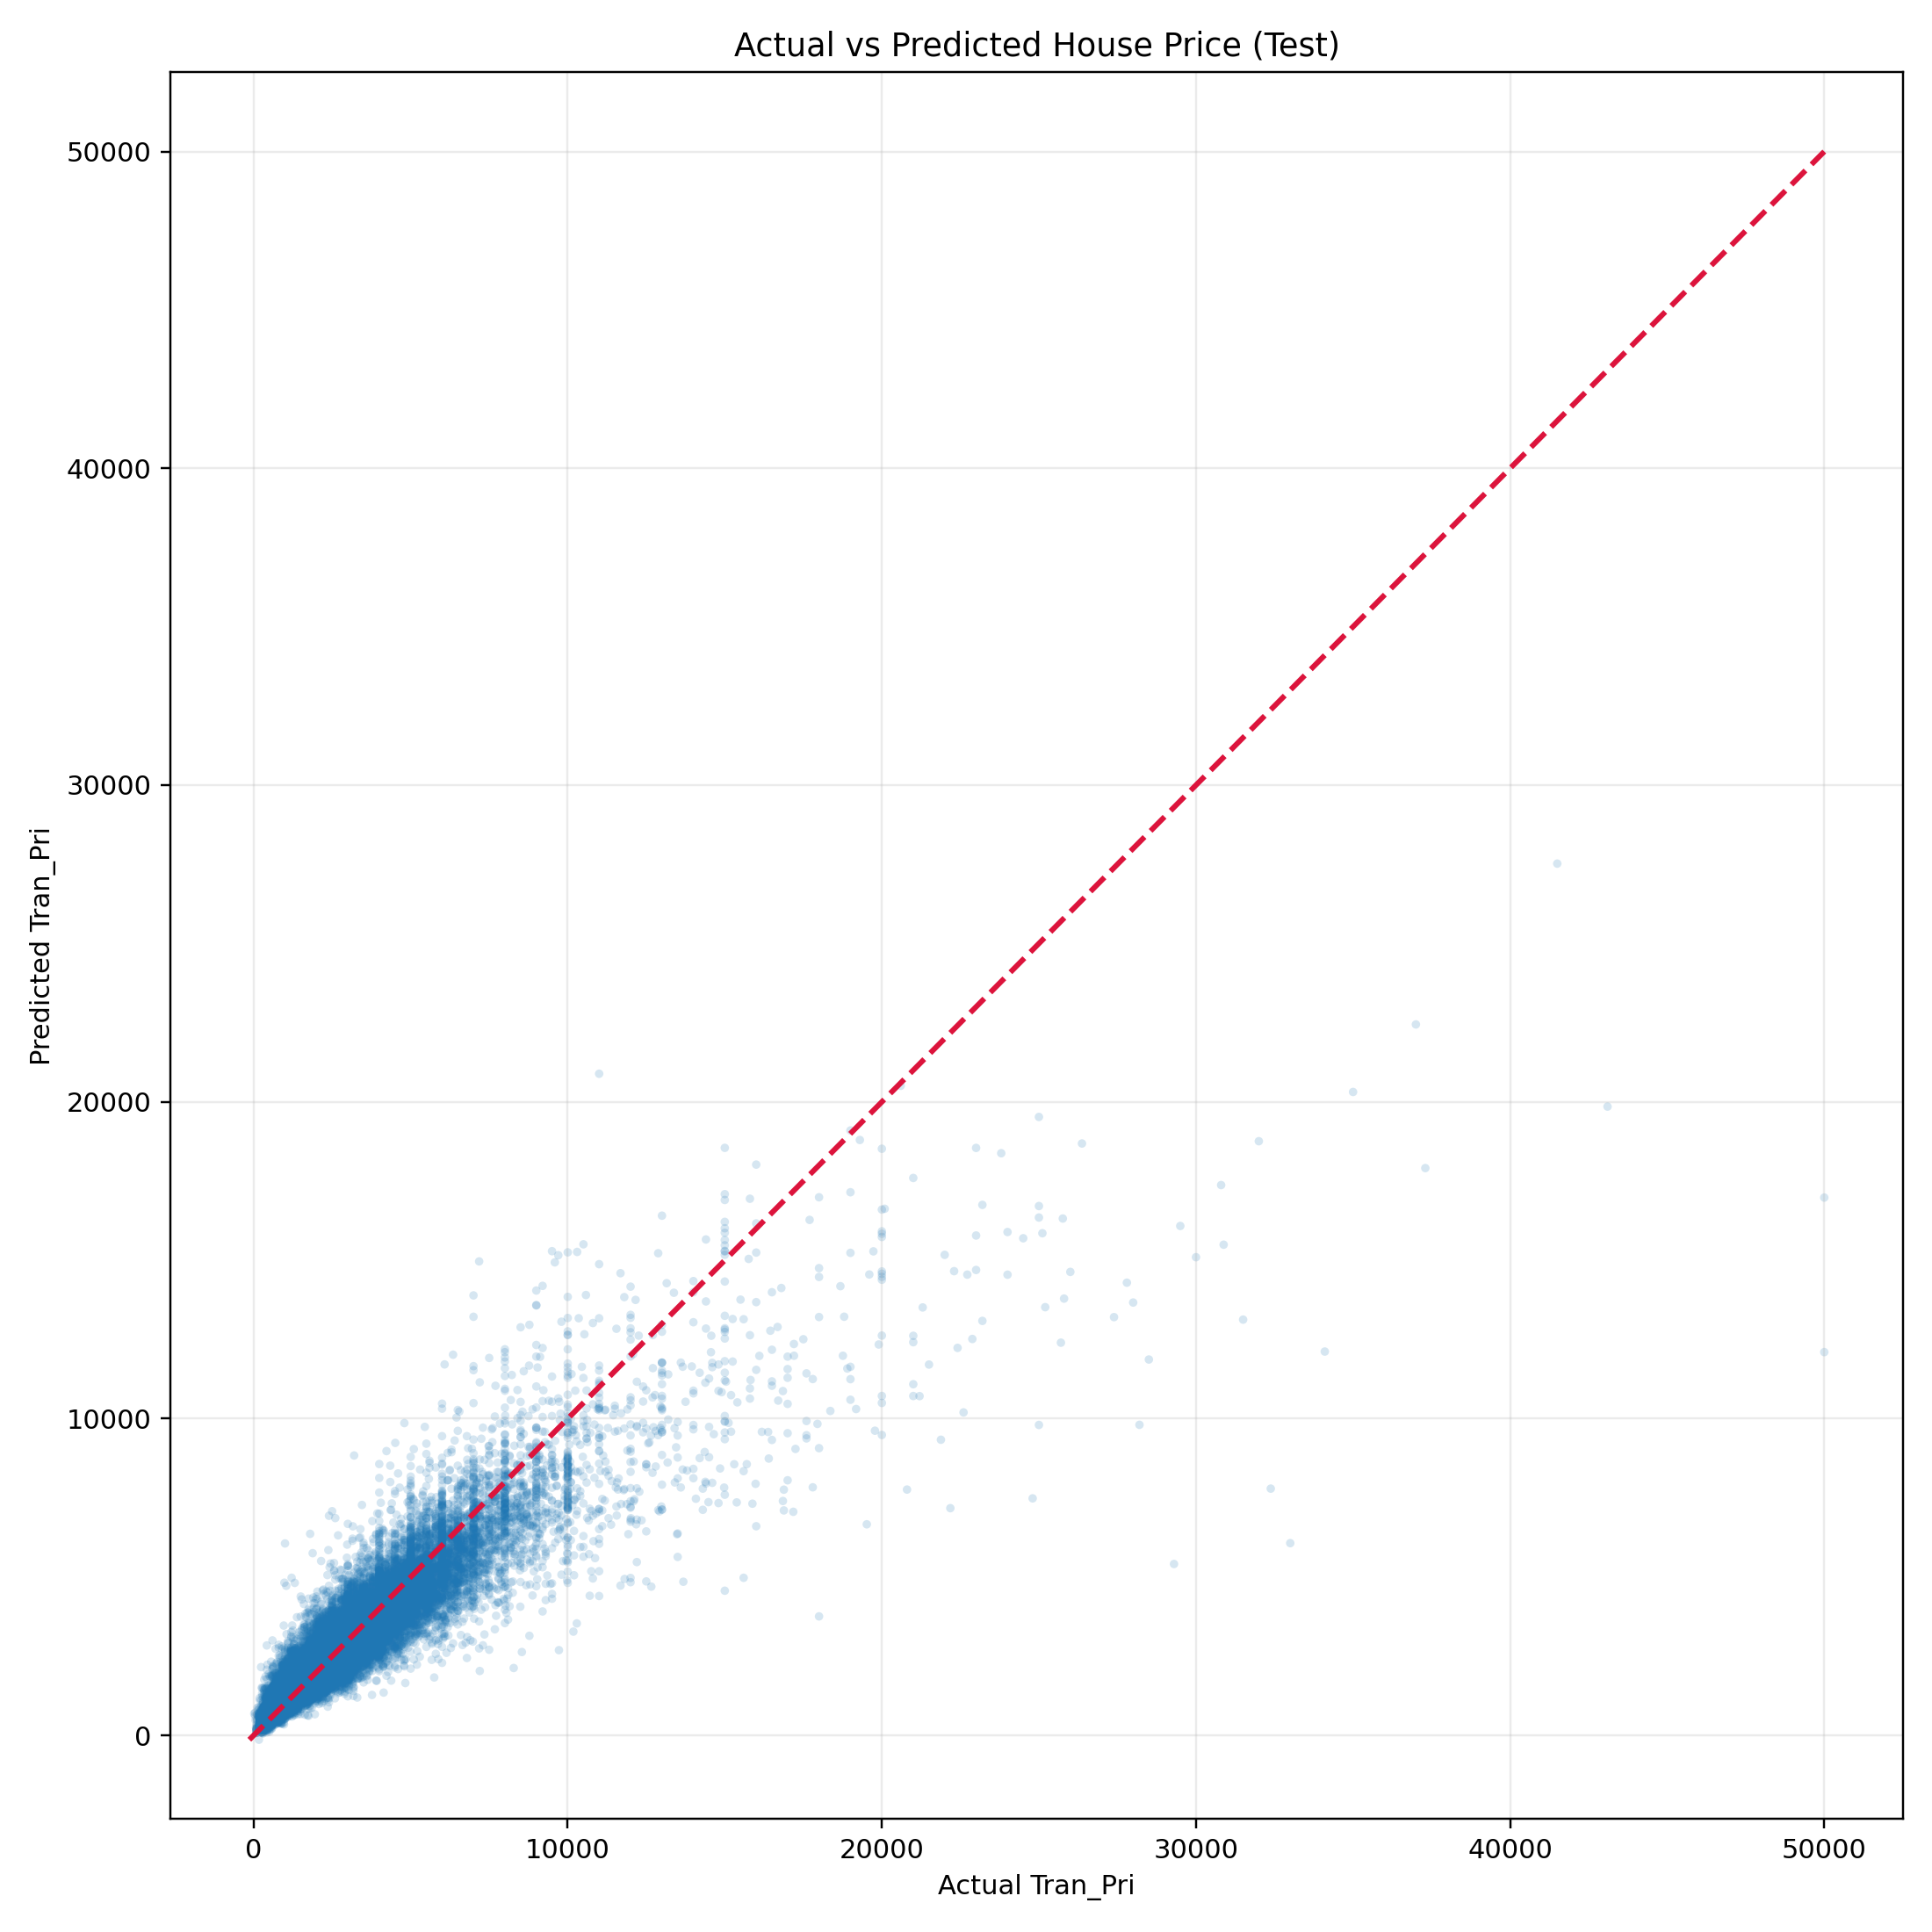


2. Actual vs Predicted (Holdout Set)


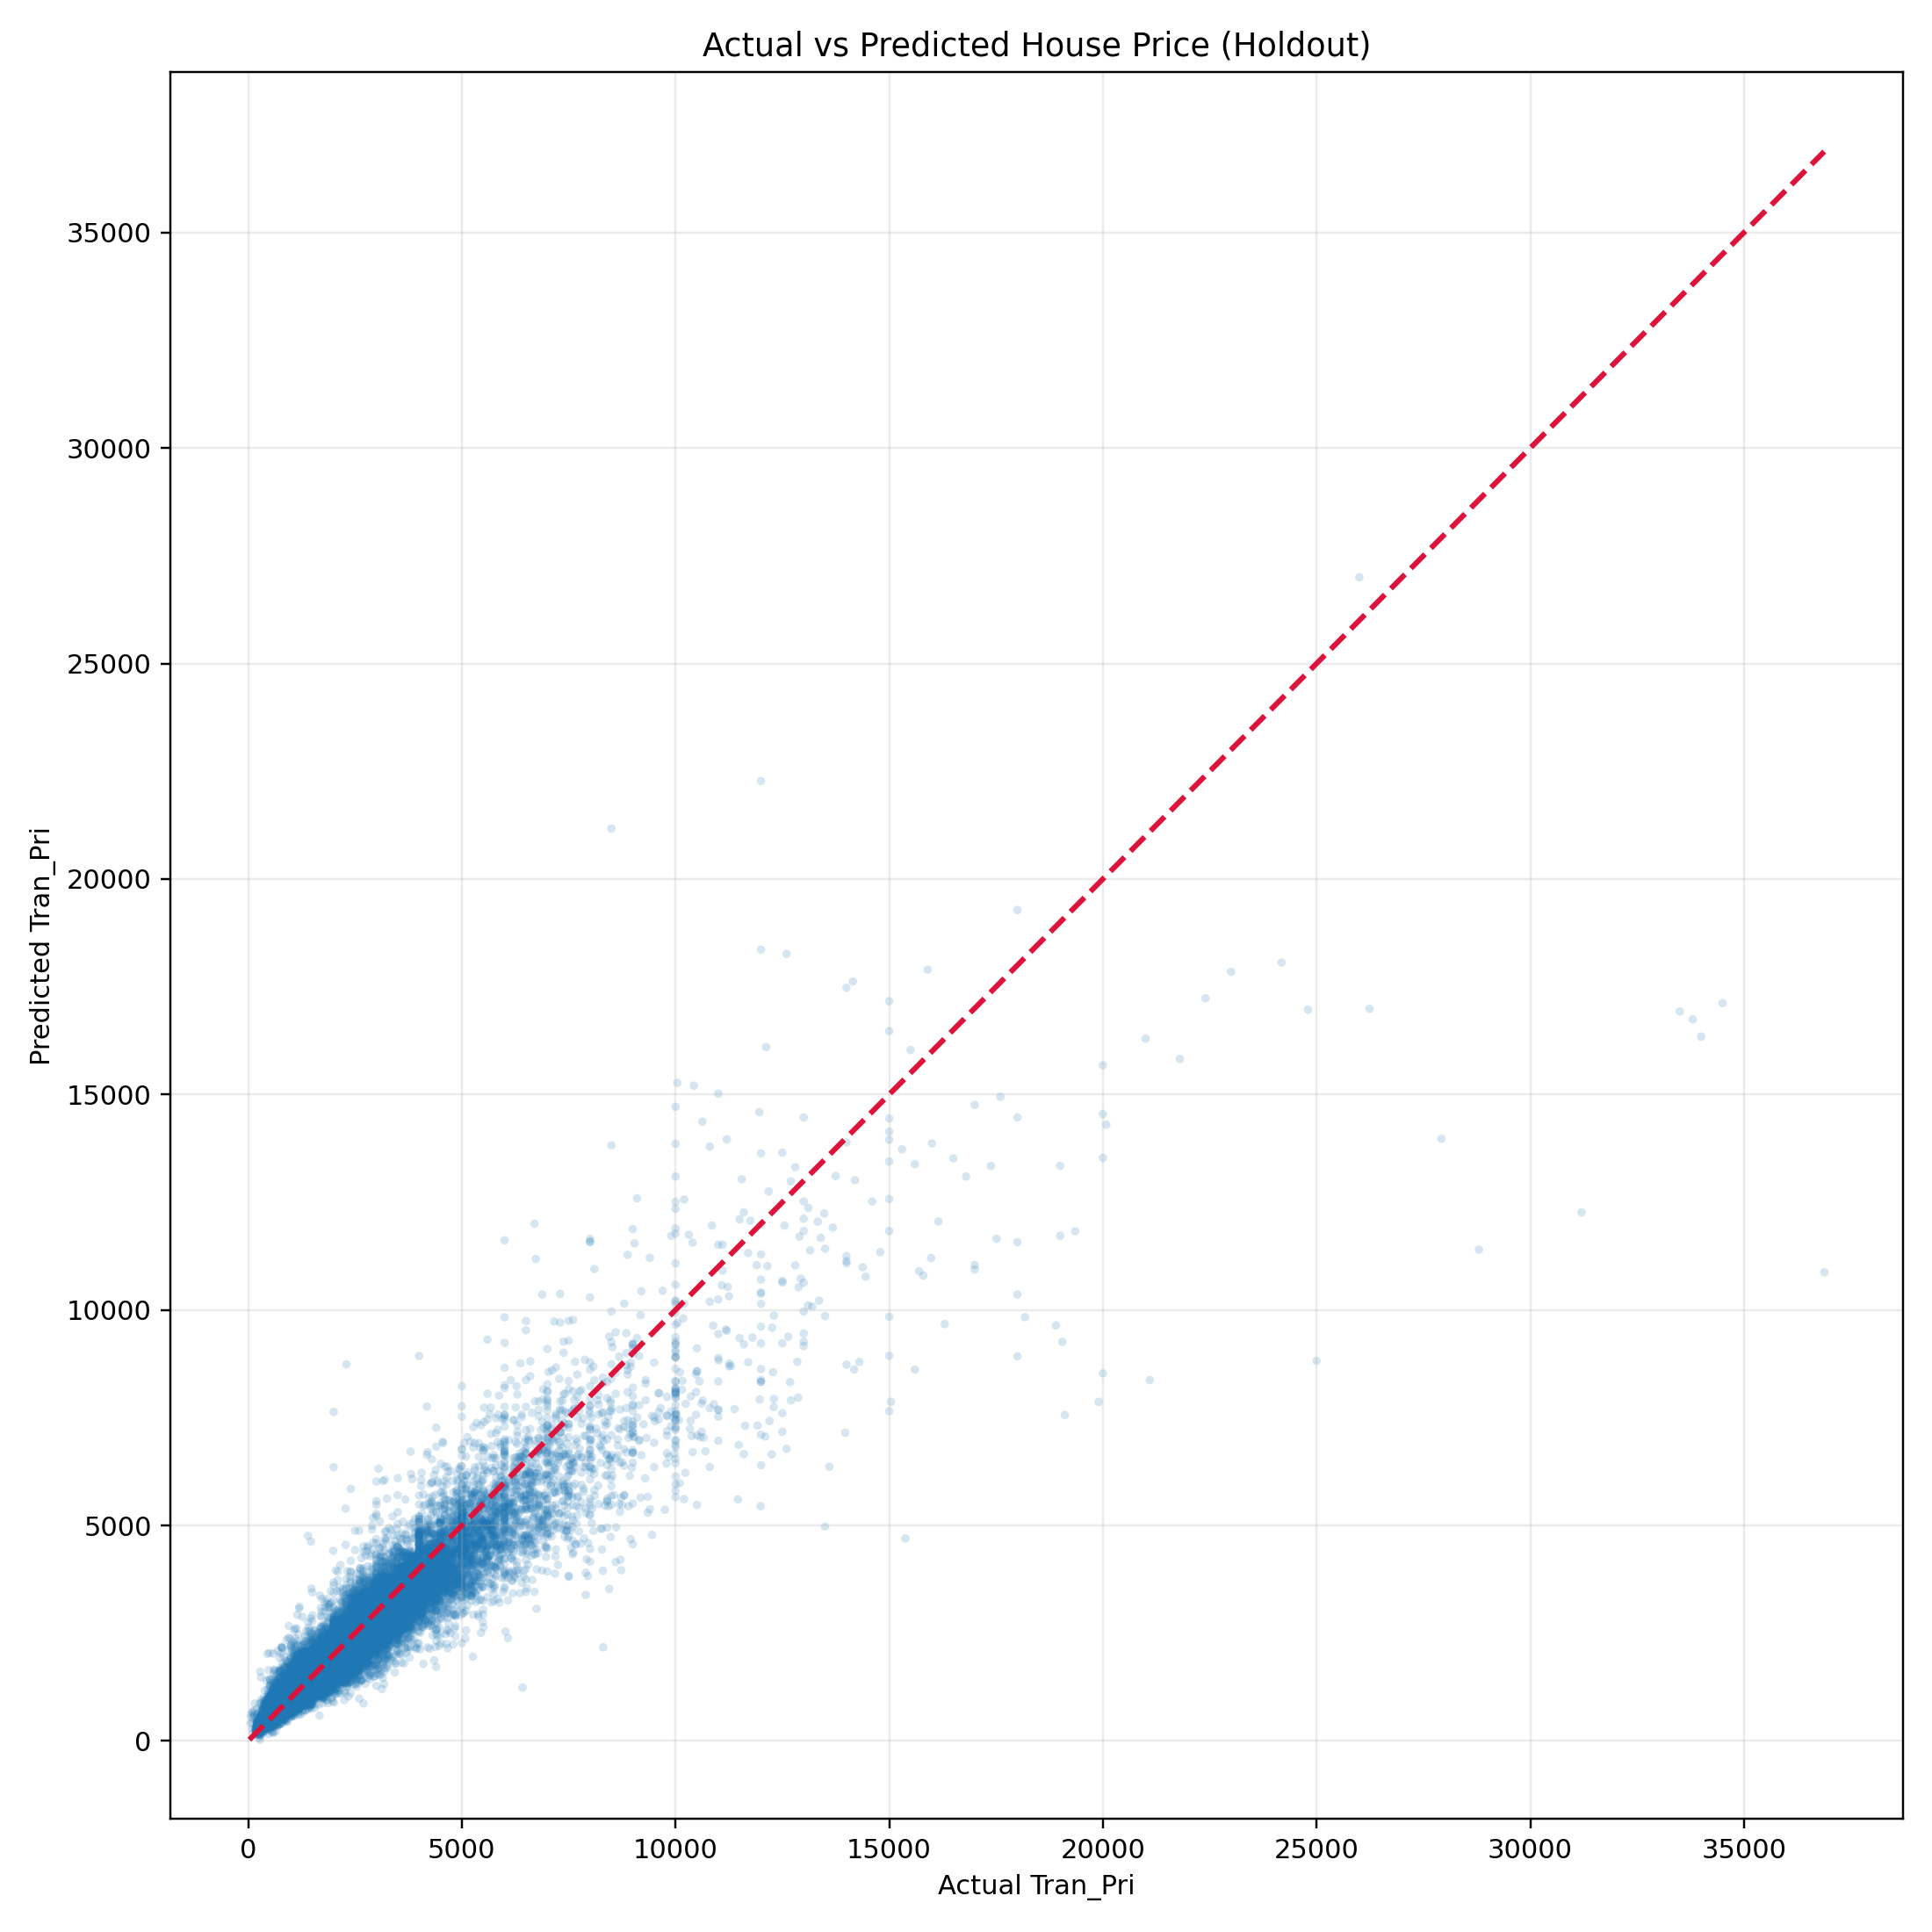


3. Metrics Comparison (RMSE, MAE, R²)


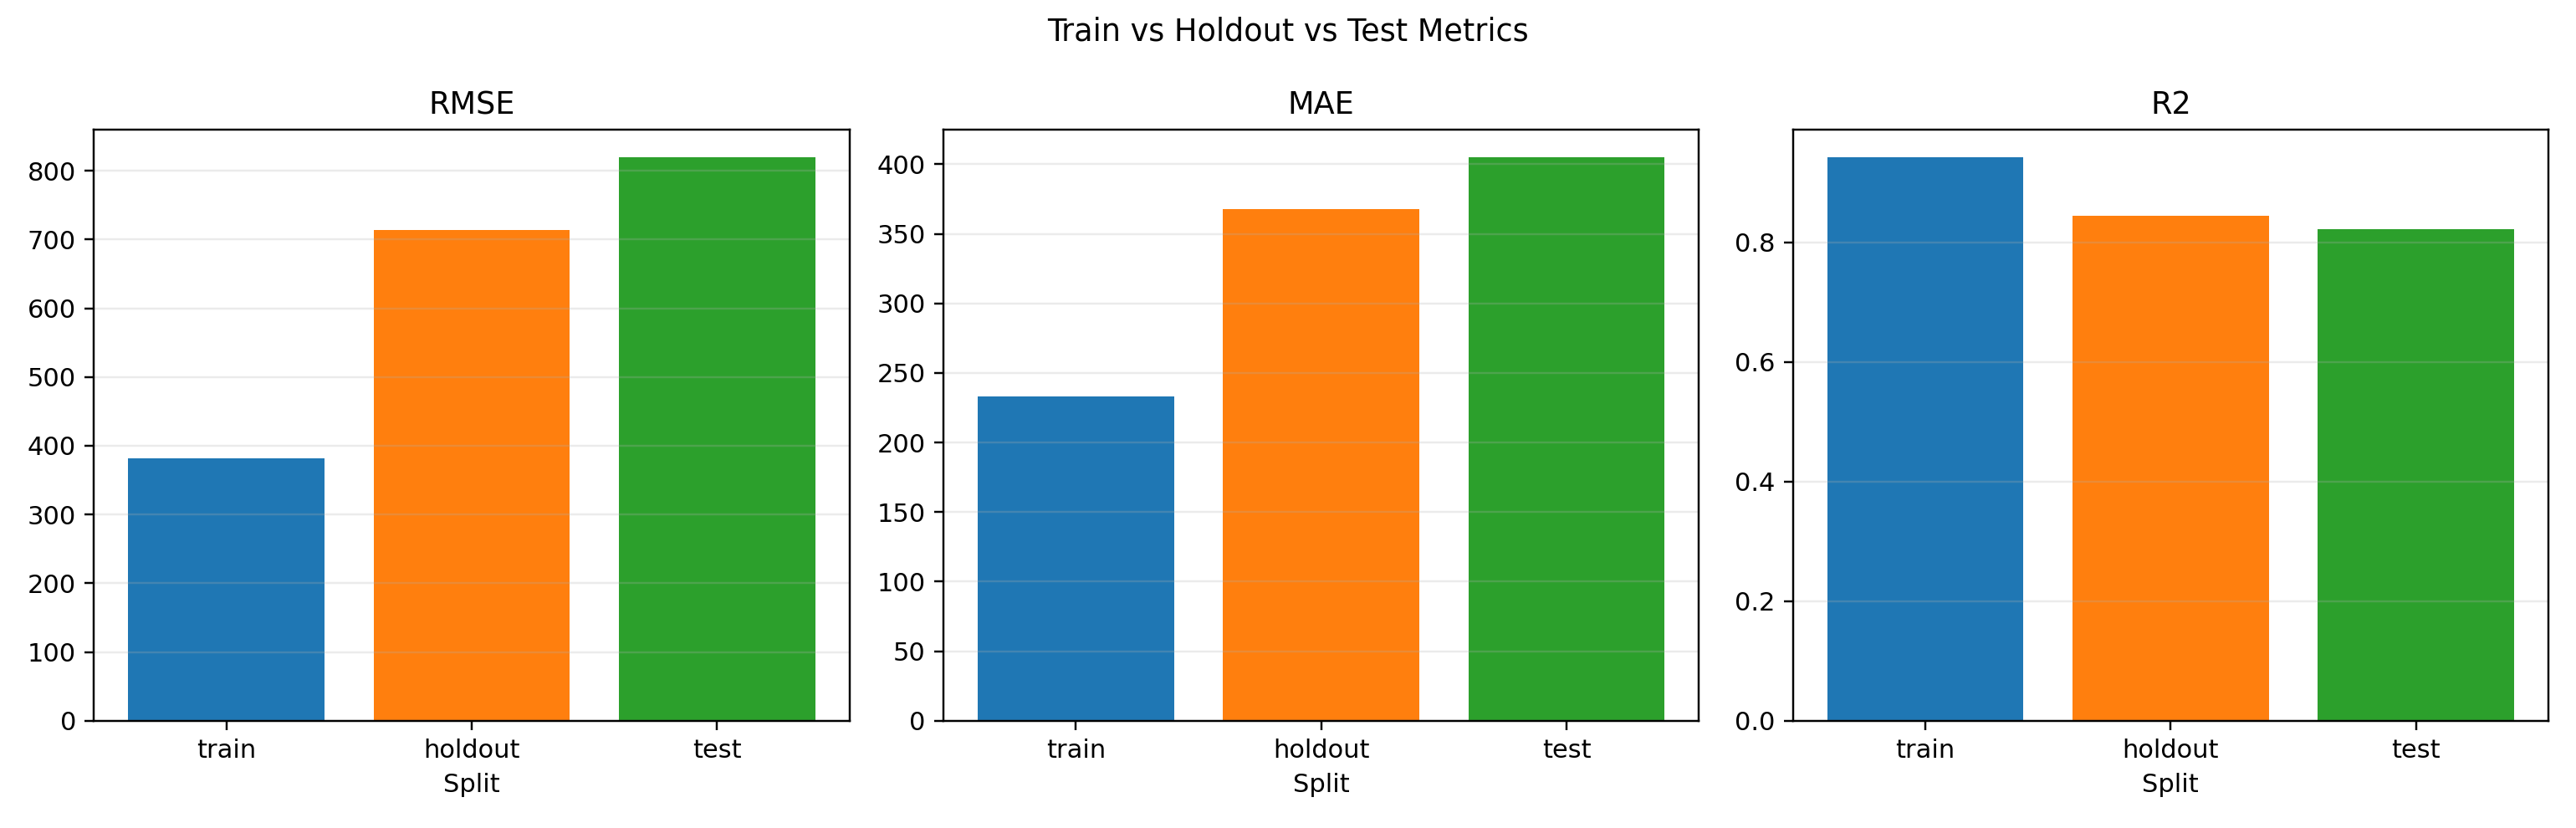


4. CatBoost Feature Importance (Top 20)


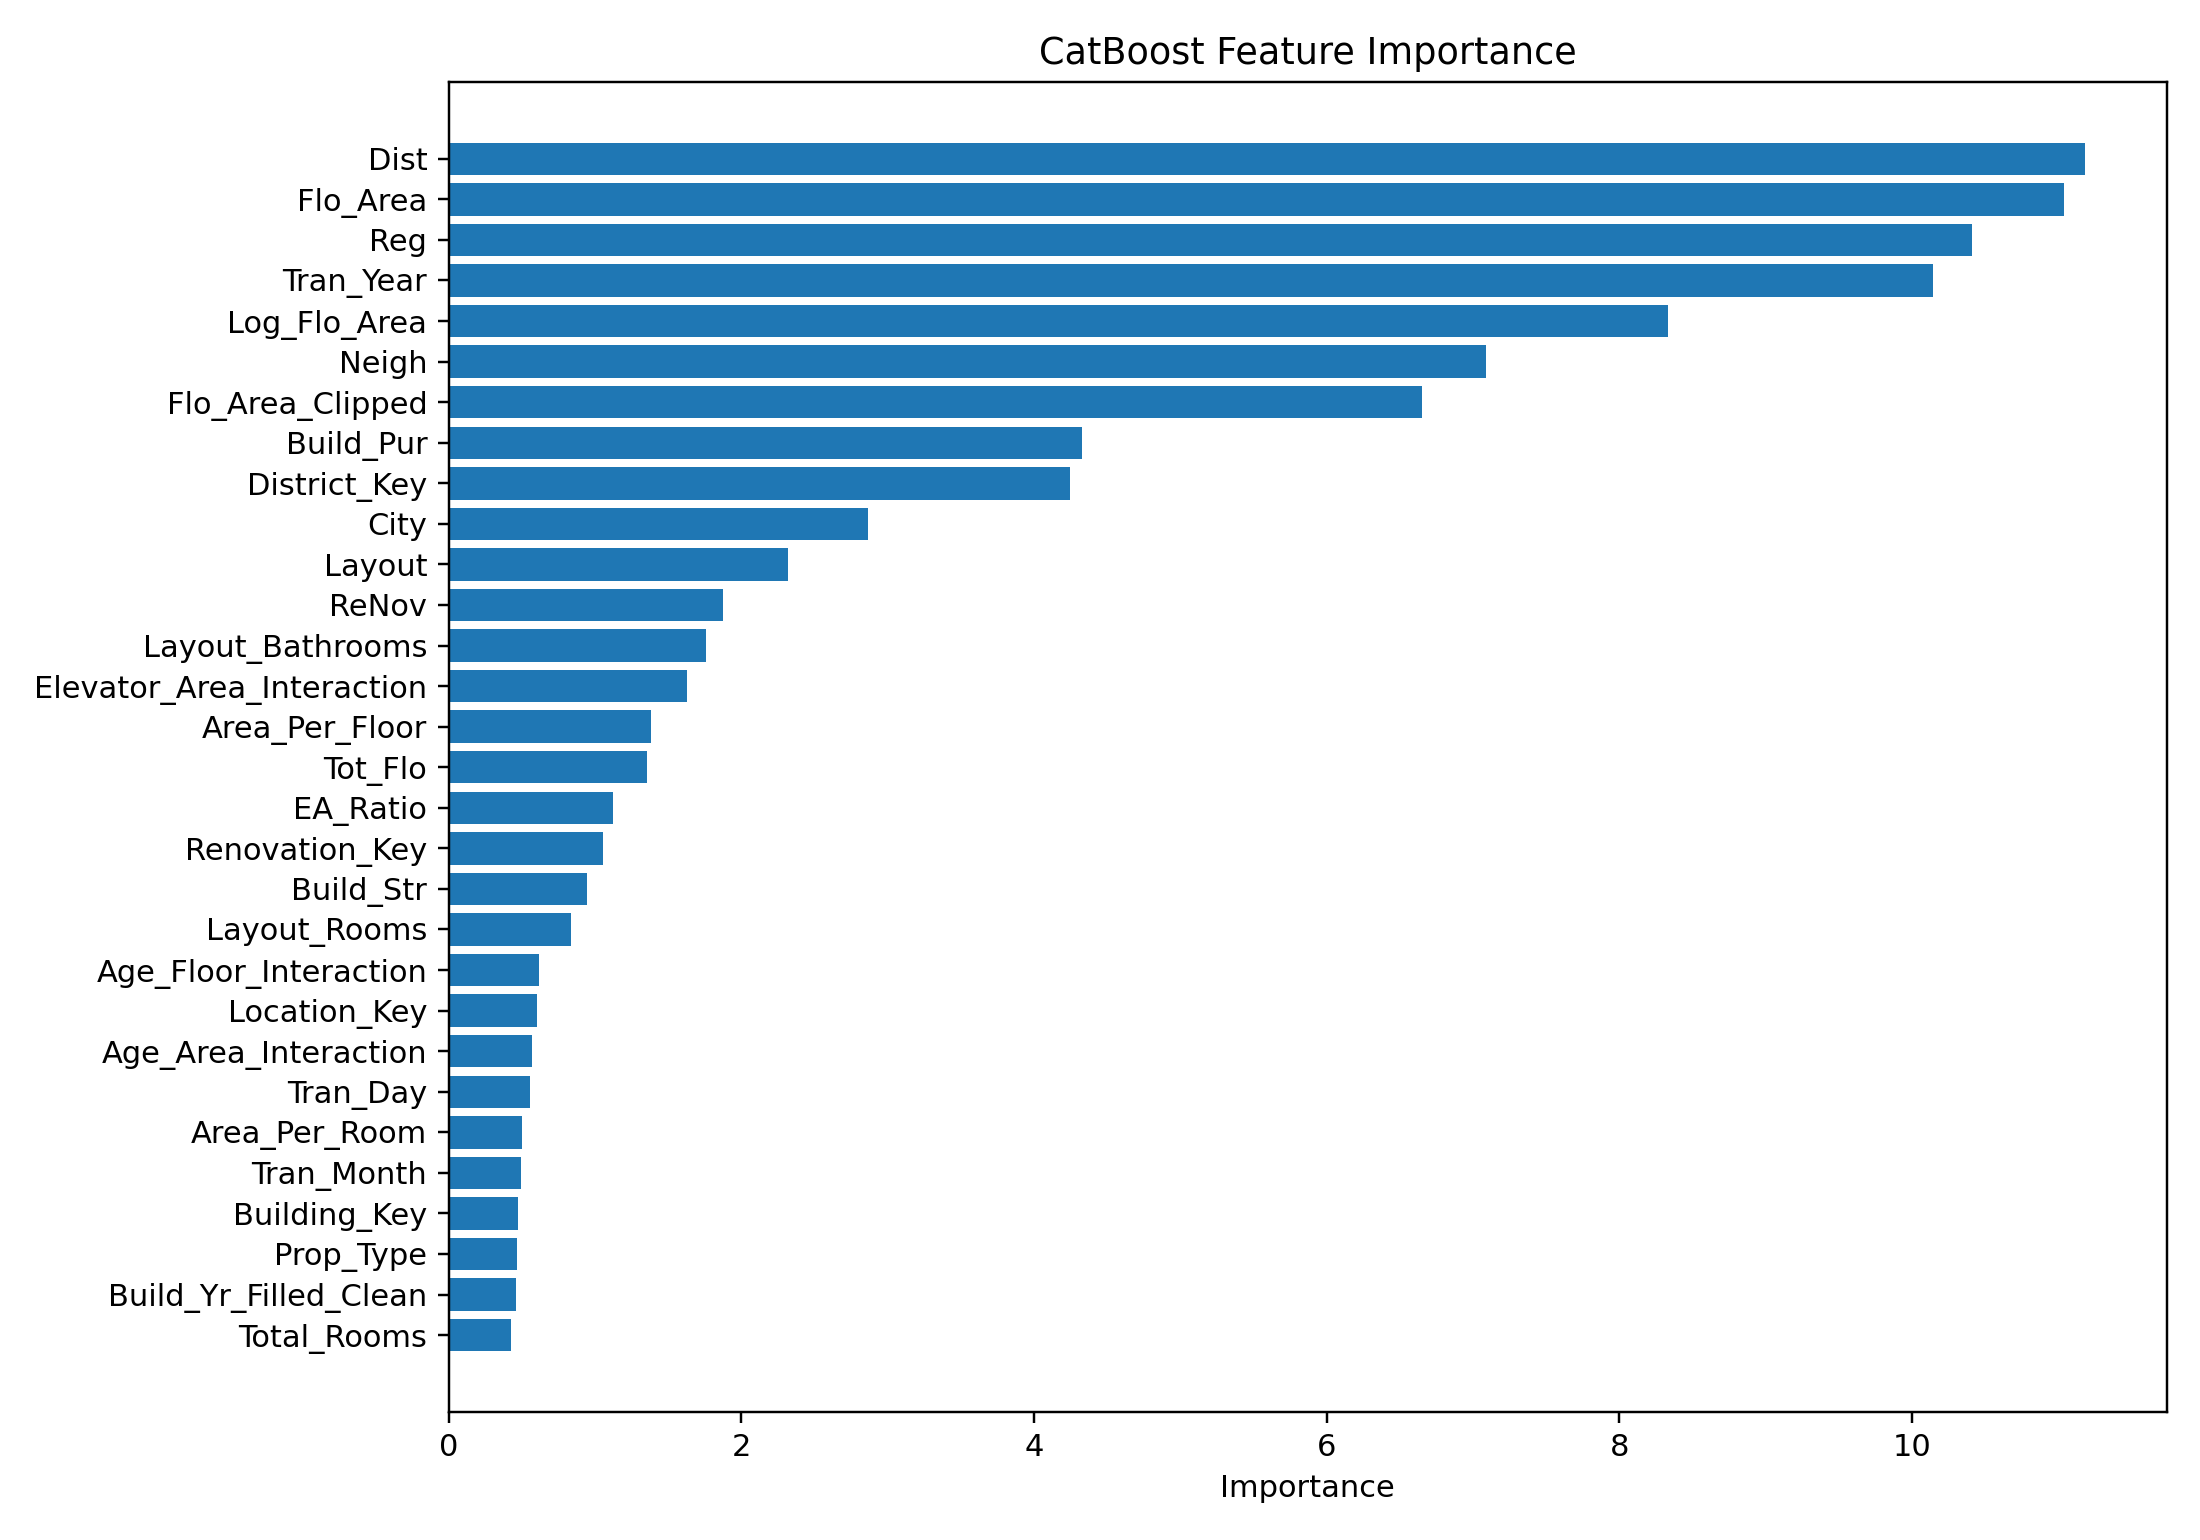


5. SHAP Feature Importance (Mean |SHAP Value|)


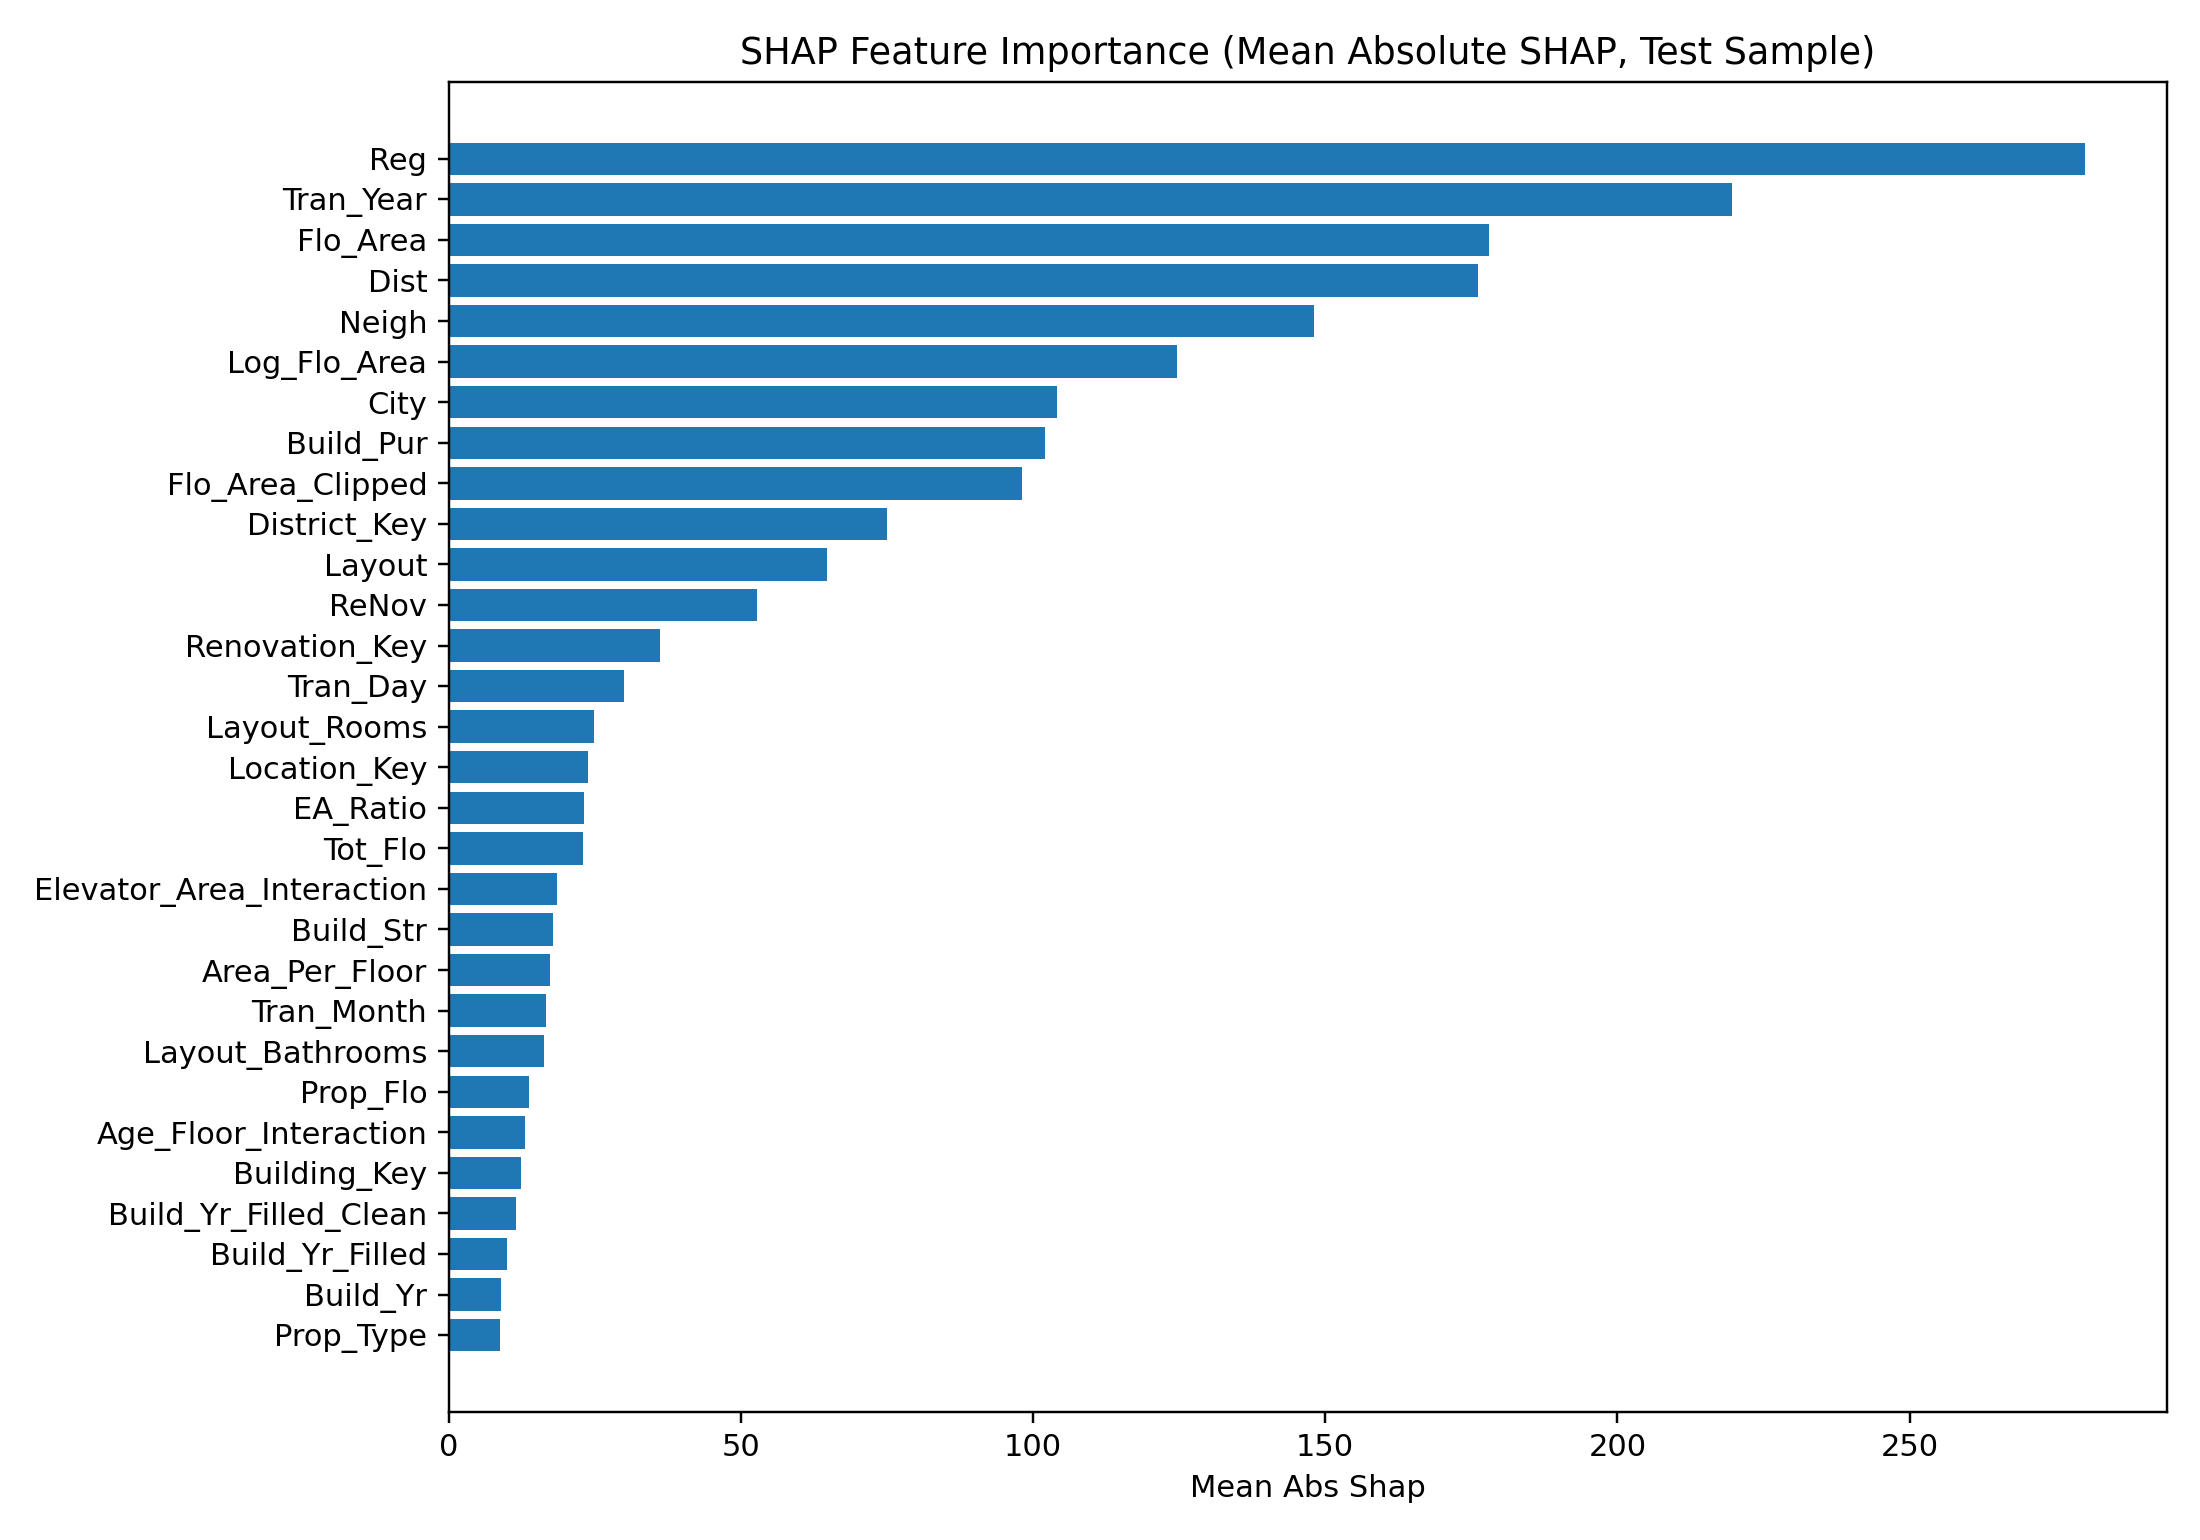


6. SHAP Beeswarm Plot (Directional Impact)


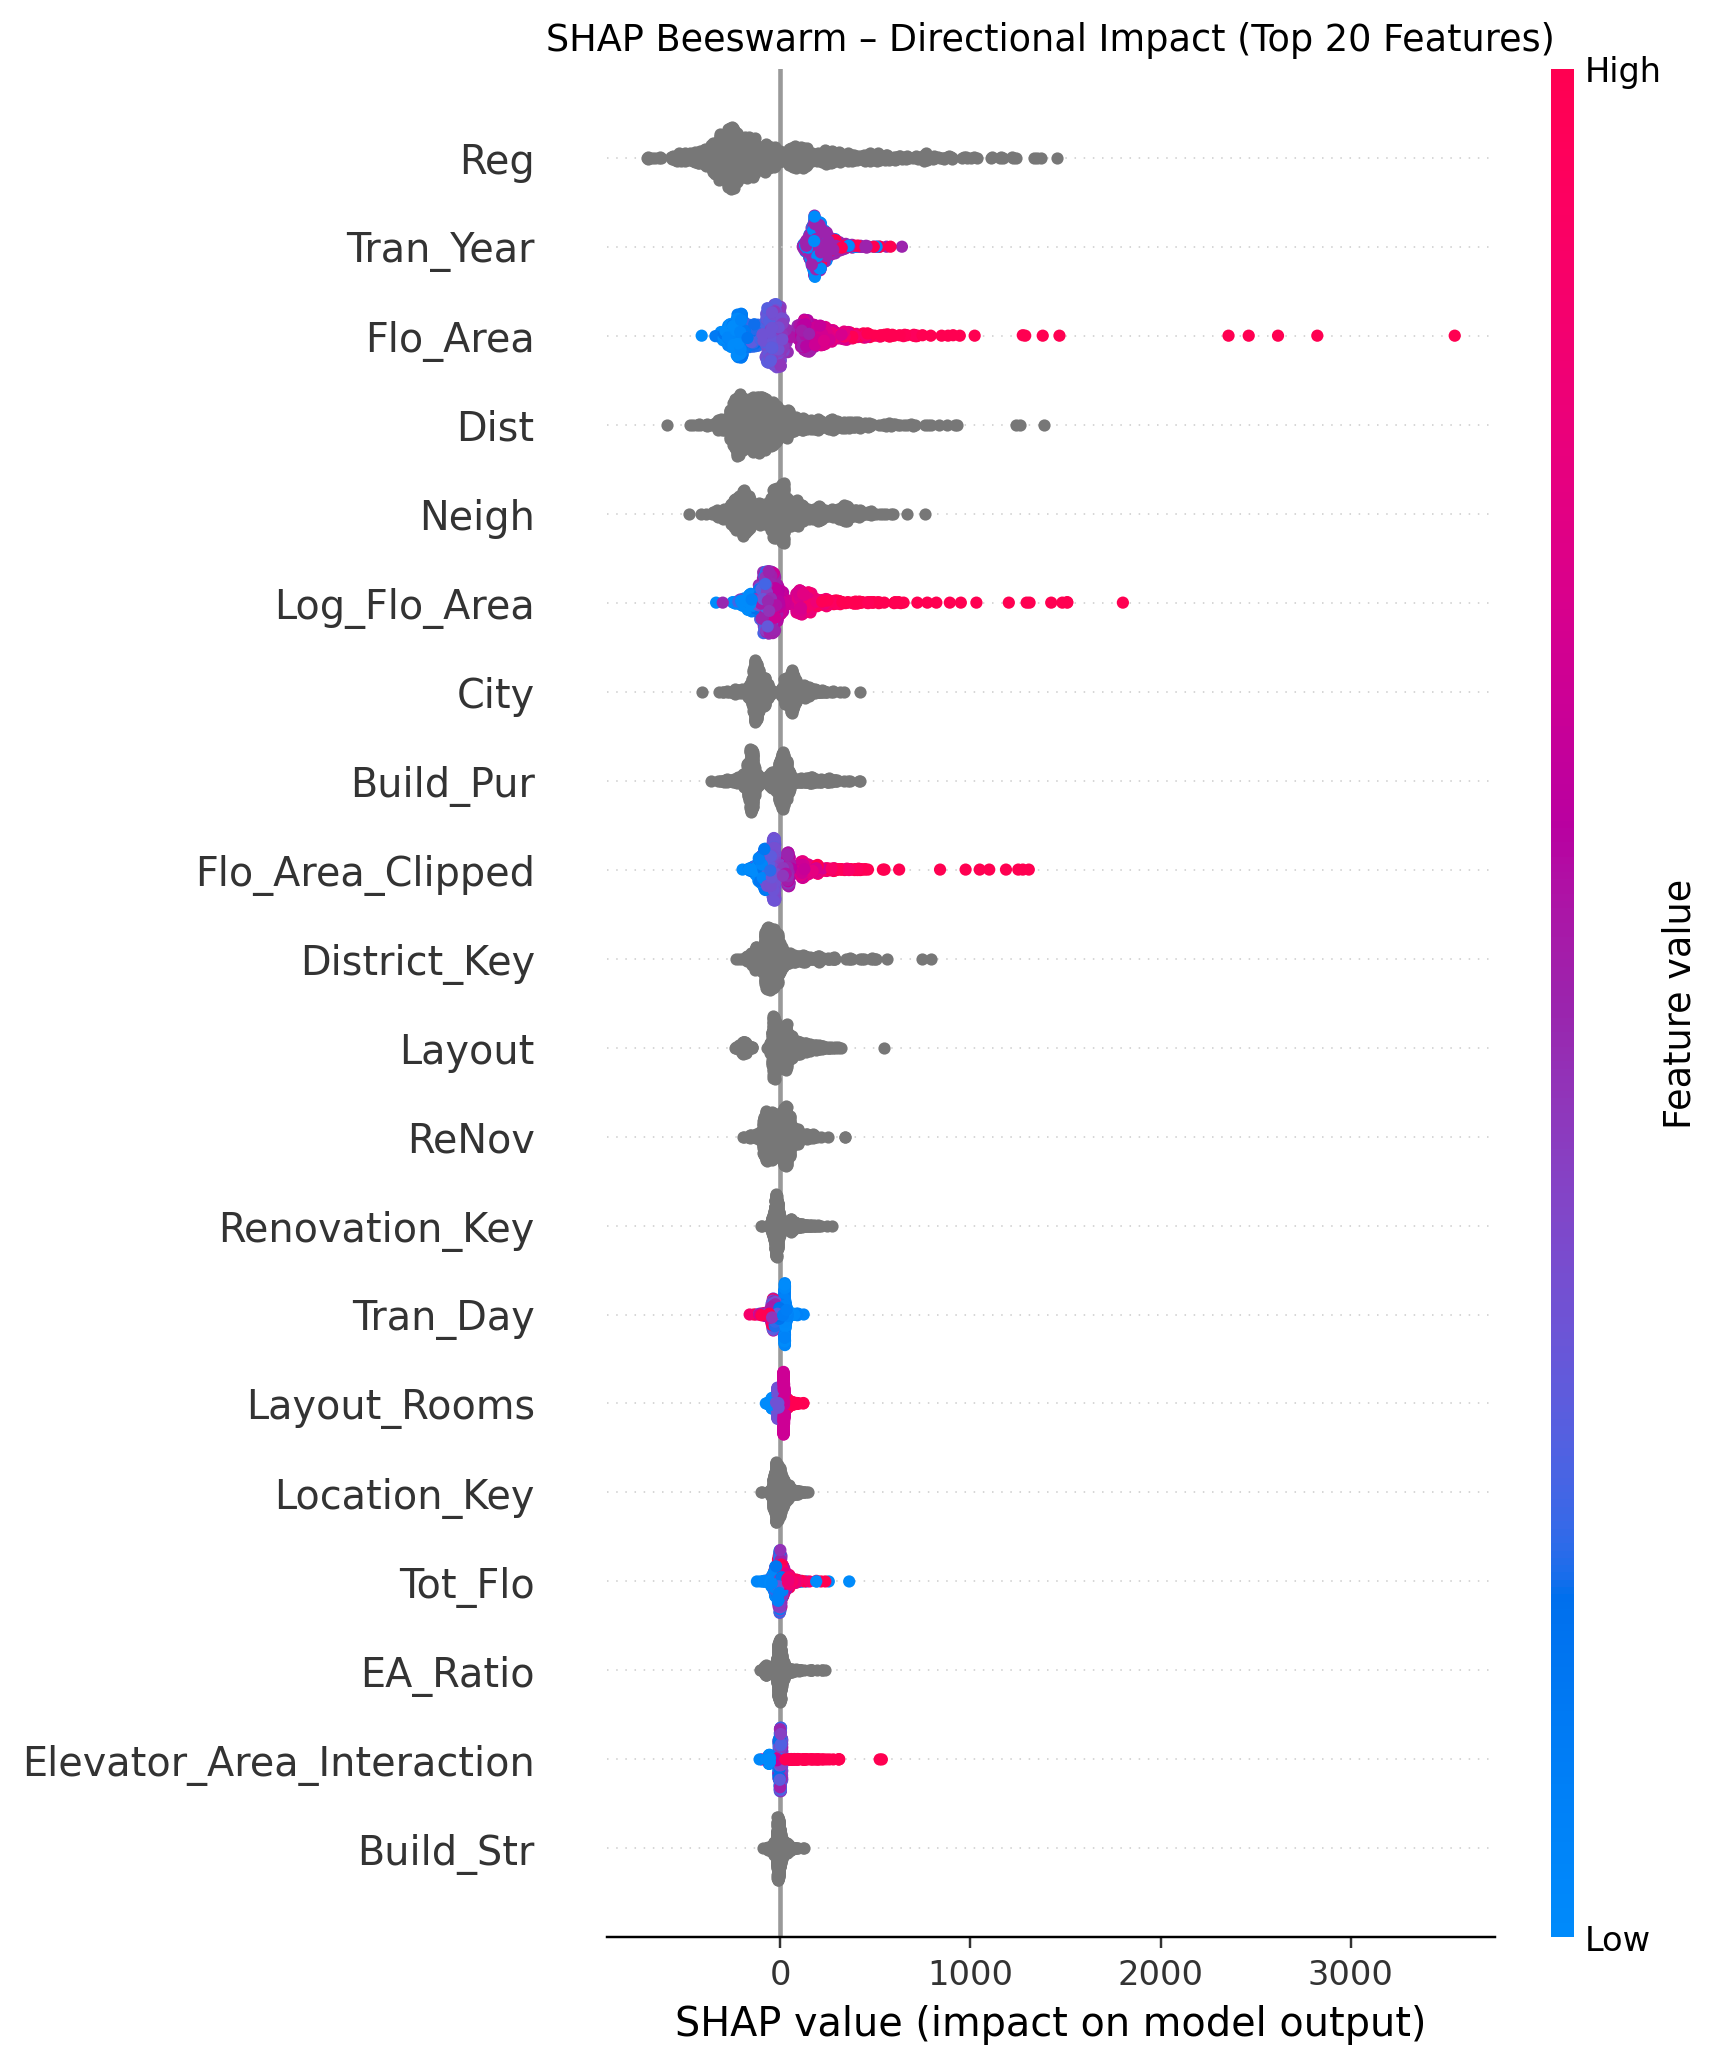


7. Residual Analysis (Test Set)


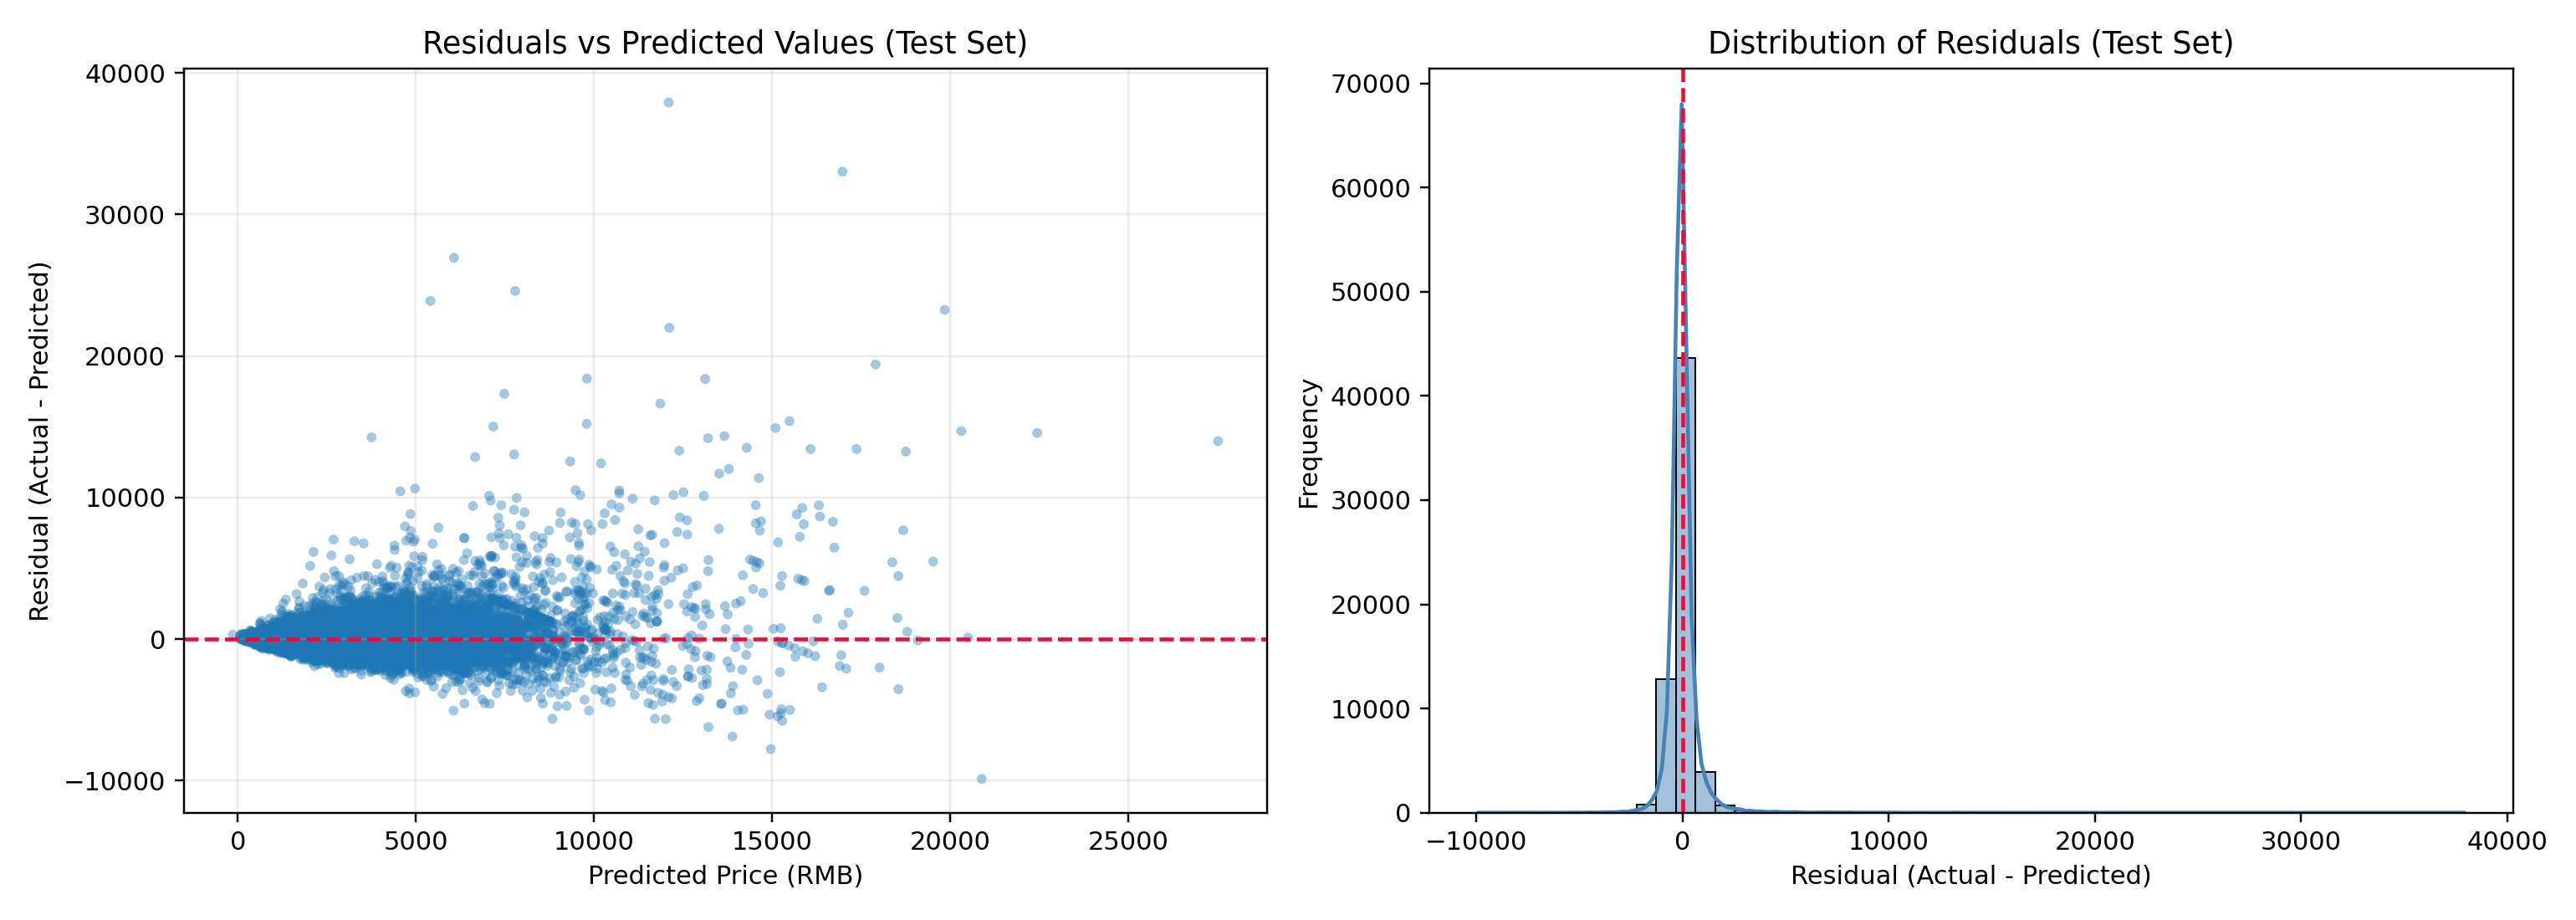


8. Residuals by Price Segment (Enhanced)


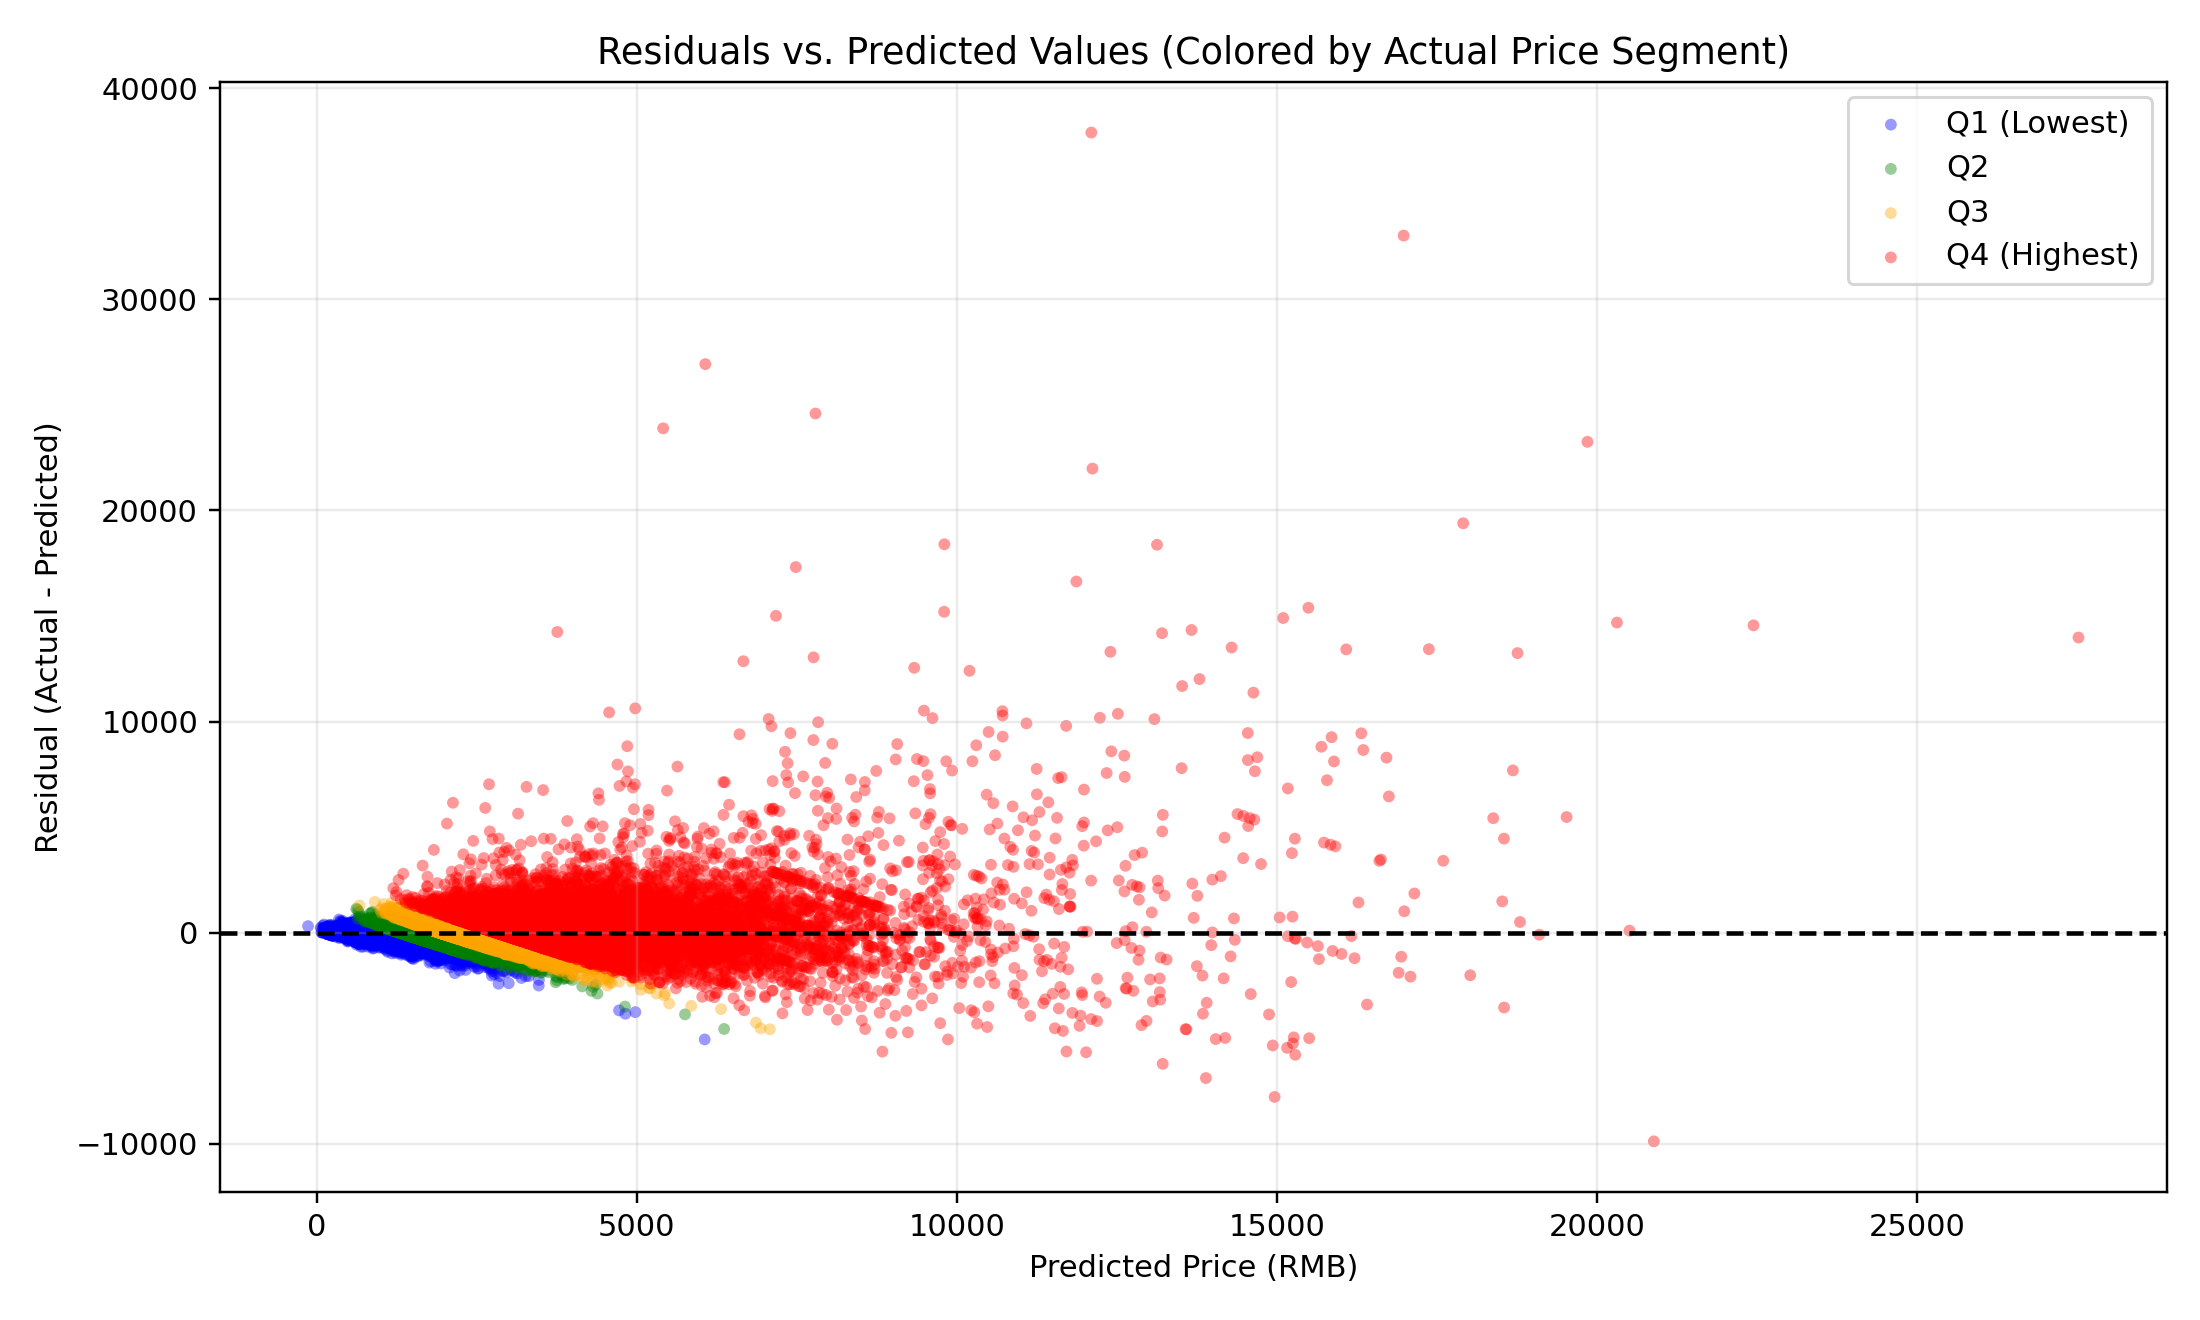


9. Learning Curves (Training vs Validation RMSE)
Image not found. Run the learning curves cell first.

All available images displayed.


In [2]:
# Display All Saved Output Images
from IPython.display import Image, display
from pathlib import Path

print("="*60)
print("Displaying saved CatBoost output images")
print("="*60)

# 1. Actual vs Predicted (Test)
print("\n1. Actual vs Predicted (Test Set)")
try:
    display(Image(filename=OUTPUT_DIR / "actual_vs_predicted.png"))
except FileNotFoundError:
    print("Image not found. Run the training cells first.")

# 2. Holdout Actual vs Predicted
print("\n2. Actual vs Predicted (Holdout Set)")
try:
    display(Image(filename=OUTPUT_DIR / "holdout_actual_vs_predicted.png"))
except FileNotFoundError:
    print("Image not found.")

# 3. Metrics Comparison (Train vs Holdout vs Test)
print("\n3. Metrics Comparison (RMSE, MAE, R²)")
try:
    display(Image(filename=OUTPUT_DIR / "metrics_comparison.png"))
except FileNotFoundError:
    print("Image not found.")

# 4. CatBoost Feature Importance
print("\n4. CatBoost Feature Importance (Top 20)")
try:
    display(Image(filename=OUTPUT_DIR / "feature_importance.png"))
except FileNotFoundError:
    print("Image not found.")

# 5. SHAP Feature Importance (Mean Absolute SHAP)
print("\n5. SHAP Feature Importance (Mean |SHAP Value|)")
try:
    display(Image(filename=OUTPUT_DIR / "shap_feature_importance.png"))
except FileNotFoundError:
    print("Image not found.")

# 6. SHAP Beeswarm Summary Plot
print("\n6. SHAP Beeswarm Plot (Directional Impact)")
try:
    display(Image(filename=OUTPUT_DIR / "shap_beeswarm_summary.png"))
except FileNotFoundError:
    print("Image not found.")

# 7. Residual Analysis (Residuals vs Predicted + Histogram)
print("\n7. Residual Analysis (Test Set)")
try:
    display(Image(filename=OUTPUT_DIR / "residual_analysis.png"))
except FileNotFoundError:
    print("Image not found.")

# 8. Residuals by Price Segment (if generated)
print("\n8. Residuals by Price Segment (Enhanced)")
try:
    display(Image(filename=OUTPUT_DIR / "residual_by_price_segment.png"))
except FileNotFoundError:
    print("Image not found. Run the error analysis cell first.")

# 9. Learning Curves (if generated)
print("\n9. Learning Curves (Training vs Validation RMSE)")
try:
    display(Image(filename=OUTPUT_DIR / "learning_curves.png"))
except FileNotFoundError:
    print("Image not found. Run the learning curves cell first.")

print("\n" + "="*60)
print("All available images displayed.")
print("="*60)

### SHAP Beeswarm Plot

Top features from CSV: ['Reg', 'Tran_Year', 'Flo_Area', 'Dist', 'Neigh', 'Log_Flo_Area', 'City', 'Build_Pur', 'Flo_Area_Clipped', 'District_Key', 'Layout', 'ReNov', 'Renovation_Key', 'Tran_Day', 'Layout_Rooms', 'Location_Key', 'EA_Ratio', 'Tot_Flo', 'Elevator_Area_Interaction', 'Build_Str']


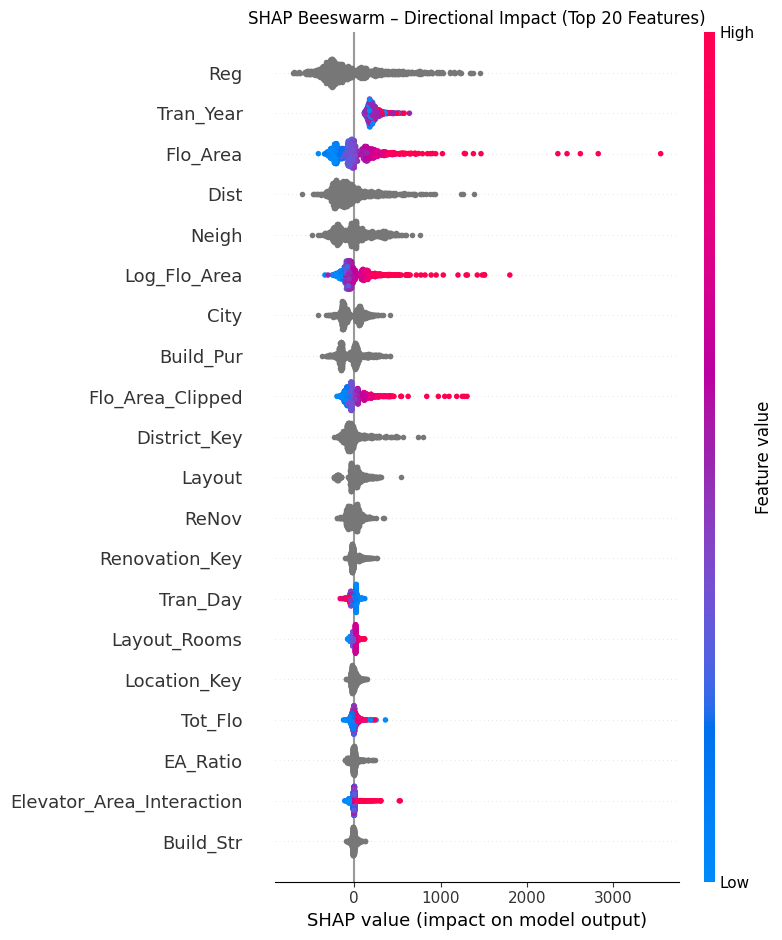

Saved SHAP beeswarm plot to: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\shap_beeswarm_summary.png


In [ ]:
# Cell: Directional SHAP Beeswarm Summary Plot
import shap
import pandas as pd
import matplotlib.pyplot as plt


# 1. Load the mean absolute SHAP importance from CSV (optional)
shap_importance_df = pd.read_csv(OUTPUT_DIR / "shap_feature_importance.csv")
top_features = shap_importance_df.head(TOP_FEATURE_COUNT)["feature"].tolist()
print("Top features from CSV:", top_features)


# 2. Sample test data and compute SHAP values (required for direction)
sample_size = min(1000, len(X_test))
sample_idx = X_test.sample(n=sample_size, random_state=RANDOM_STATE).index
X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

cat_feature_indices = [X_test.columns.get_loc(col) for col in categorical_columns]
shap_pool = Pool(X_sample, y_sample, cat_features=cat_feature_indices)

# Get full SHAP matrix (last column is the expected value)
shap_values_full = model.get_feature_importance(shap_pool, type="ShapValues")
shap_matrix = shap_values_full[:, :-1]


# 3. Optionally filter to top features only
# Get indices of top features in the original feature order
top_indices = [X_test.columns.get_loc(f) for f in top_features if f in X_test.columns]
shap_matrix_filtered = shap_matrix[:, top_indices]
X_sample_filtered = X_sample.iloc[:, top_indices]


# 4. Create beeswarm summary plot
plt.figure()
shap.summary_plot(
    shap_matrix_filtered,
    X_sample_filtered,
    feature_names=X_sample_filtered.columns.tolist(),
    plot_type="dot",
    show=False
)
plt.title(f"SHAP Beeswarm – Directional Impact (Top {TOP_FEATURE_COUNT} Features)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm_summary.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

print("Saved SHAP beeswarm plot to:", OUTPUT_DIR / "shap_beeswarm_summary.png")


## 13. Final Summary

This final cell prints the main metrics dictionary so the overall model performance and configuration are easy to review in one place.


In [27]:

print(json.dumps(metrics, indent=2))
comparison_df


{
  "model": "CatBoostRegressor",
  "training_iterations": 1500,
  "best_iteration": 1499,
  "holdout_strategy": "time-based last 20% of TRAIN.csv by Tran_Dt",
  "train_period": {
    "start": "2012.11.22",
    "end": "2021.02.20"
  },
  "holdout_period": {
    "start": "2021.02.20",
    "end": "2021.06.30"
  },
  "test_period": {
    "start": "2021.07.01",
    "end": "2023.02.13"
  },
  "feature_engineering": [
    "time-based holdout split using Tran_Dt",
    "month, quarter, day-of-week, and cyclic month features",
    "cleaned build year, age, and age flags",
    "clipped area, log area, and area-per-room / area-per-floor features",
    "parsed layout counts from Layout",
    "parsed elevator/apartment counts from EA_Ratio",
    "floor-level coding and rise-type flags",
    "lift / renovation flags and interaction features",
    "location, layout, building, and renovation composite categorical keys"
  ],
  "split_metrics": {
    "train": {
      "rows": 132646,
      "rmse": 381.41

,split,rows,rmse,mae,r2
0,train,132646,381.416401,233.192593,0.941705
1,holdout,33162,713.754795,368.029817,0.843921
2,test,62733,819.181767,404.848942,0.821505


## 14. Save the Full Test File with Predictions

This section saves the original test dataset exactly as loaded, then appends the CatBoost prediction column so the full test file can be reviewed outside the notebook. If the true target is present, a residual column is also added.

In [28]:
full_test_predictions_path = OUTPUT_DIR / 'test_full_with_predictions.csv'

full_test_with_predictions_df = test_df.copy()
full_test_with_predictions_df['predicted_tran_pri'] = test_predictions

if TARGET_COLUMN in full_test_with_predictions_df.columns:
    full_test_with_predictions_df['residual'] = (
        full_test_with_predictions_df[TARGET_COLUMN] - full_test_with_predictions_df['predicted_tran_pri']
    )

full_test_with_predictions_df.to_csv(full_test_predictions_path, index=False)
print('Saved:', full_test_predictions_path)
full_test_with_predictions_df.head()


Saved: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\test_full_with_predictions.csv


,City,Reg,Dist,Neigh,Tran_Dt,Tran_Day,Tran_Pri,Layout,Prop_Flo,Tot_Flo,...,Build_Str,EA_Ratio,Lift,Prop_Type,Build_Pur,Total_Rooms,Build_Yr_Filled,Elevator_Density,predicted_tran_pri,residual
0,Hangzhou,Qiantangqu,Jinshahu,Dejiajinshayangguang,2021.07.01,765,2130,2Room2Livingroom1Kitchen1Bathroom,Upper floor,28.0,...,Frame,2E4A,Yes,Commercial property,Normal residence,4,2013.0,0.50,2668.238701,-538.238701
1,Hangzhou,Gongshu,Daguan,Daguanxiqiyuan,2021.07.01,379,1900,2Room1Livingroom1Kitchen1Bathroom,Middle floor,6.0,...,Brick hybrid,1E2A,No,Commercial property,Normal residence,3,2013.0,0.50,1925.731260,-25.731260
2,Ningbo,Jiangbeiqu,Jiangbeiwanda,Yinyiyudingyuan,2021.07.01,115,3160,2Room2Livingroom1Kitchen1Bathroom,Upper floor,16.0,...,Steel hybrid,1E4A,No,Commercial property,Normal residence,4,2013.0,0.25,2956.877801,203.122199
3,Ningbo,Beilunqu,Xinqi,Sijiguihuayuanyiguiyuan,2021.07.01,56,3250,2Room2Livingroom1Kitchen1Bathroom,Lower floor,7.0,...,Steel hybrid,1E2A,No,Commercial property,Normal residence,4,2010.0,0.50,2204.530538,1045.469462
4,Hangzhou,Xihu,Sandun,Jindizizaichengmanaowan,2021.07.01,235,5400,3Room2Livingroom1Kitchen2Bathroom,Middle floor,25.0,...,Steel hybrid,2E4A,Yes,Commercial property,Normal residence,5,2013.0,0.50,4759.562123,640.437877


### Residuals Histogram

Loaded 62733 rows from actual_vs_predicted.csv
Columns: ['actual_tran_pri', 'predicted_tran_pri', 'residual']

Residual Summary Statistics:
count    62733.000000
mean         0.733049
std        819.187968
min      -9888.009107
25%       -293.083915
50%        -62.731563
75%        180.424734
max      37899.450381
Name: residual, dtype: float64


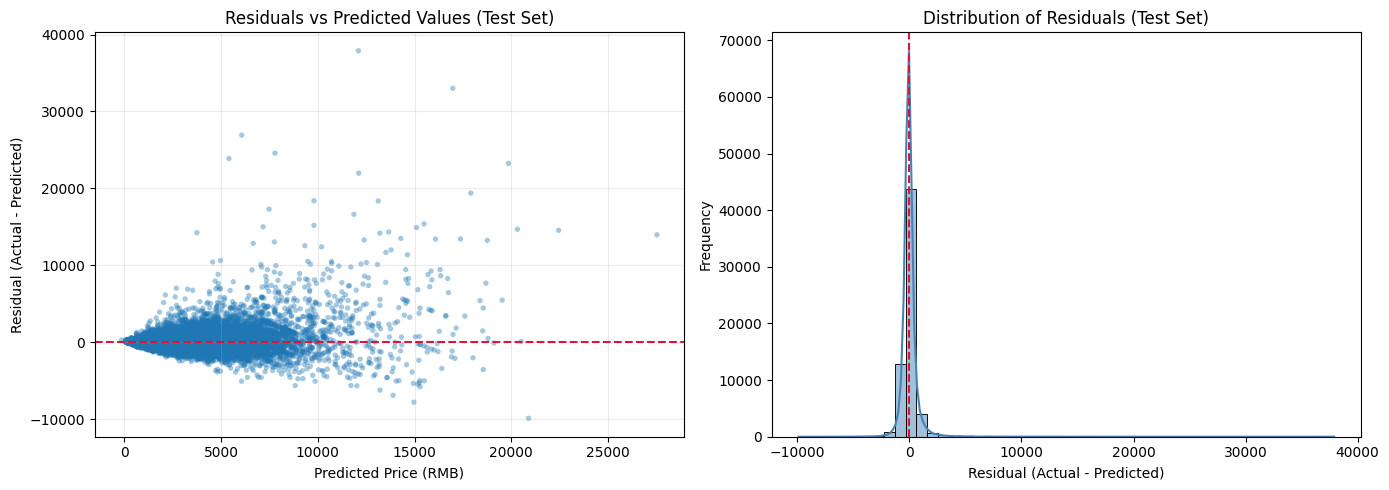

Residual plots saved to: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\residual_analysis.png


In [ ]:
# Calculate residuals
pred_df = pd.read_csv(OUTPUT_DIR / 'actual_vs_predicted.csv')
print(f"Loaded {len(pred_df)} rows from actual_vs_predicted.csv")
print("Columns:", pred_df.columns.tolist())

# Extract actual, predicted, and residual columns
y_actual = pred_df['actual_tran_pri']
y_pred = pred_df['predicted_tran_pri']
residuals = pred_df['residual']

print("\nResidual Summary Statistics:")
print(residuals.describe())

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, edgecolors='none', s=15)
axes[0].axhline(y=0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price (RMB)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values (Test Set)')
axes[0].grid(alpha=0.25)

#  Plot 2: Histogram of Residuals 
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals (Test Set)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_analysis.png', dpi=220)
plt.show()
plt.close()

print("Residual plots saved to:", OUTPUT_DIR / 'residual_analysis.png')

## 15. Rerun with New File(Optional)
It loads the trained model and preprocessing parameters, applies the exact same feature engineering, and saves the results.

Prerequisite: This cell assumes the notebook has already been run up to the point where build_features is defined, the model is trained, and preprocessing_info.json has been saved (i.e., after the final output cell). Adjust NEW_DATA_PATH to point to your actual file.

In [ ]:
# Cell: Predict on New Data (e.g., test2.csv)
import pandas as pd
import json
from catboost import CatBoostRegressor
from pathlib import Path


# 1. Specify the new data file
NEW_DATA_PATH = BASE_DIR.parent / "data" / "YOUR_FILE_NAME.csv"   # Adjust path as needed
OUTPUT_PREDICTIONS_PATH = OUTPUT_DIR / "YOUR_FILE_NAME_RESULT.csv"

# Check if file exists
if not NEW_DATA_PATH.exists():
    raise FileNotFoundError(f"New data file not found: {NEW_DATA_PATH}")


# 2. Load the trained model and preprocessing info
model = CatBoostRegressor()
model.load_model(OUTPUT_DIR / 'catboost_house_price_model.cbm')

with open(OUTPUT_DIR / 'preprocessing_info.json', 'r') as f:
    info = json.load(f)


# 3. Load and prepare the new data
new_df = pd.read_csv(NEW_DATA_PATH)
print(f"Loaded {len(new_df)} rows from {NEW_DATA_PATH}")

# Apply the SAME feature engineering used during training
X_new, _, _, _ = build_features(new_df, area_clip_bounds=info['area_clip_bounds'])

# Ensure columns match the training order
X_new = X_new[info['feature_columns']]


# 4. Generate predictions
new_df['predicted_tran_pri'] = model.predict(X_new)

# If true target exists, also compute residual
if TARGET_COLUMN in new_df.columns:
    new_df['residual'] = new_df[TARGET_COLUMN] - new_df['predicted_tran_pri']


# 5. Save the results
new_df.to_csv(OUTPUT_PREDICTIONS_PATH, index=False)
print(f"Predictions saved to: {OUTPUT_PREDICTIONS_PATH}")

# Preview the first few predictions
print("\nPreview of predictions:")
display(new_df[['Tran_Dt', 'City', 'Flo_Area', TARGET_COLUMN, 'predicted_tran_pri', 'residual']].head(10)
        if TARGET_COLUMN in new_df.columns 
        else new_df[['Tran_Dt', 'City', 'Flo_Area', 'tran_pri', 'predicted_tran_pri']].head(10))

Loaded 4 rows from d:\MACHINE LEARNING\knn_catboost\data\TEST copy.csv
Predictions saved to: d:\MACHINE LEARNING\knn_catboost\catboost\outputs\test2_with_predictions.csv

Preview of predictions:


,Tran_Dt,City,Flo_Area,Tran_Pri,predicted_tran_pri,residual
0,2021.07.01,Hangzhou,87.10,2130,2668.238701,-538.238701
1,2021.07.01,Hangzhou,54.40,1900,1925.731260,-25.731260
2,2021.07.01,Ningbo,88.47,3160,2956.877801,203.122199
3,2021.07.01,Ningbo,87.21,3250,2204.530538,1045.469462


## Robustness Checks and Additional Metrics

To ensure the CatBoost model's performance is not coincidental or overfitted to a specific data split, we perform three robustness checks:

### 1. Expanding-Window Temporal Cross-Validation
We train the model on an expanding history and validate on each subsequent year (2018–2021). This simulates a realistic forecasting scenario where only past data is available. A stable R² across folds indicates that the model does not rely on future leakage and generalises well across time.

### 2. City-Subset Generalisation (Leave-Hangzhou-Out)
Because Hangzhou dominates the dataset (55% of transactions), we train the model on all cities except Hangzhou and test exclusively on Hangzhou. This checks whether the model learns truly general price drivers or overfits to Hangzhou‑specific patterns. A reasonably high R² on Hangzhou suggests transferability.

### 3. Extreme Price Sensitivity (Outlier Removal)
We remove the top 1% and bottom 1% of transaction prices from the training set and retrain the model. We then compare performance on the original test set, paying special attention to luxury properties (>6M RMB). This reveals whether a few extreme values disproportionately influence the model.

### 4. Mean Absolute Percentage Error (MAPE)
MAE and RMSE are scale‑dependent. MAPE provides a relative error measure (percentage), which is more intuitive for buyers. We compute MAPE for train, holdout, and test splits to assess relative accuracy.

The code below implements these checks and prints the results.

In [ ]:
# Robustness Check 1: Expanding-Window Temporal Cross-Validation
print("="*60)
print("Robustness Check 1: Expanding-Window Temporal Cross-Validation")
print("="*60)

# Reload raw training data to avoid contamination
train_raw = pd.read_csv(TRAIN_PATH)

# Sort by transaction date
tran_dt = pd.to_datetime(train_raw["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
train_sorted = train_raw.assign(_tran_dt=tran_dt).sort_values("_tran_dt").drop(columns="_tran_dt")

# Define years for folds (2014-2021)
years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
results_expanding = []

for i, year in enumerate(years[1:], start=1):
    # Training: up to previous year
    train_up_to = train_sorted[train_sorted["Tran_Dt"] <= f"{years[i-1]}.12.31"]
    # Validation: the specified year
    val_year = train_sorted[train_sorted["Tran_Dt"].str.startswith(str(year))]
    
    if len(train_up_to) == 0 or len(val_year) == 0:
        continue
        
    # Build features (use area_clip_bounds from full training to be consistent)
    X_tr, y_tr, cat_cols, bounds = build_features(train_up_to)
    X_val, y_val, _, _ = build_features(val_year, area_clip_bounds=bounds)
    
    # Train CatBoost with same hyperparameters
    model_cv = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=500,  # reduced for speed; you can increase
        learning_rate=0.04,
        depth=9,
        l2_leaf_reg=4.0,
        subsample=0.85,
        random_seed=RANDOM_STATE,
        verbose=False,
        early_stopping_rounds=50,
        allow_writing_files=False,
    )
    model_cv.fit(X_tr, y_tr, cat_features=cat_cols, eval_set=(X_val, y_val), use_best_model=True, verbose=False)
    
    # Evaluate
    pred_val = model_cv.predict(X_val)
    r2 = r2_score(y_val, pred_val)
    mae = mean_absolute_error(y_val, pred_val)
    results_expanding.append({"fold": f"Train up to {years[i-1]}", "val_year": year, "R2": r2, "MAE": mae})
    print(f"Fold {i}: Train up to {years[i-1]}, validate {year} -> R2={r2:.4f}, MAE={mae:.2f}")

expanding_df = pd.DataFrame(results_expanding)
print("\nExpanding Window Summary:")
print(expanding_df.describe())

Robustness Check 1: Expanding-Window Temporal Cross-Validation
Fold 1: Train up to 2014, validate 2015 -> R2=0.6314, MAE=390.10
Fold 2: Train up to 2015, validate 2016 -> R2=0.6910, MAE=373.94
Fold 3: Train up to 2016, validate 2017 -> R2=0.5275, MAE=667.03
Fold 4: Train up to 2017, validate 2018 -> R2=0.6688, MAE=654.16
Fold 5: Train up to 2018, validate 2019 -> R2=0.8184, MAE=361.83
Fold 6: Train up to 2019, validate 2020 -> R2=0.7994, MAE=409.14
Fold 7: Train up to 2020, validate 2021 -> R2=0.7986, MAE=447.81

Expanding Window Summary:
          val_year        R2         MAE
count     7.000000  7.000000    7.000000
mean   2018.000000  0.705033  472.001858
std       2.160247  0.107195  131.793103
min    2015.000000  0.527537  361.830853
25%    2016.500000  0.650120  382.019078
50%    2018.000000  0.691049  409.140517
75%    2019.500000  0.798986  550.986419
max    2021.000000  0.818430  667.030645


In [ ]:
# Robustness Check 2: City-Subset Generalisation (Train without Hangzhou)
print("\n" + "="*60)
print("Robustness Check 2: City-Subset Generalisation")
print("="*60)

# Split training data into Hangzhou and non-Hangzhou
train_hz = train_split_df[train_split_df["City"] == "Hangzhou"]
train_other = train_split_df[train_split_df["City"] != "Hangzhou"]

# Build features for both
X_train_hz, y_train_hz, cat_hz, bounds_hz = build_features(train_hz)
X_train_other, y_train_other, cat_other, bounds_other = build_features(train_other)

# Build test set (Hangzhou only) using same bounds as non-Hangzhou training
test_hz = test_df[test_df["City"] == "Hangzhou"]
X_test_hz, y_test_hz, _, _ = build_features(test_hz, area_clip_bounds=bounds_other)

# Train model on non-Hangzhou data
model_no_hz = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,
    learning_rate=0.04,
    depth=9,
    l2_leaf_reg=4.0,
    subsample=0.85,
    random_seed=RANDOM_STATE,
    verbose=False,
    early_stopping_rounds=80,
    allow_writing_files=False,
)
model_no_hz.fit(X_train_other, y_train_other, cat_features=cat_other, verbose=False)

# Predict on Hangzhou test set
pred_hz = model_no_hz.predict(X_test_hz)
r2_hz = r2_score(y_test_hz, pred_hz)
mae_hz = mean_absolute_error(y_test_hz, pred_hz)
print(f"Train on all except Hangzhou, test on Hangzhou only:")
print(f"R2 = {r2_hz:.4f}, MAE = {mae_hz:.2f}")


Robustness Check 2: City-Subset Generalisation
Train on all except Hangzhou, test on Hangzhou only:
R2 = -0.0507, MAE = 1535.87


In [ ]:
# Robustness Check 3: Extreme Price Sensitivity (Remove top/bottom 1%)
print("\n" + "="*60)
print("Robustness Check 3: Extreme Price Sensitivity")
print("="*60)


# 1. Reload raw training and test data from CSV
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)


# 2. Recreate time-based split (same as in the main notebook)
def time_holdout_split(df: pd.DataFrame, holdout_size: float):
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    ordered_df = df.assign(_tran_dt=tran_dt).sort_values("_tran_dt").drop(columns="_tran_dt")
    split_idx = int(len(ordered_df) * (1 - holdout_size))
    return ordered_df.iloc[:split_idx].copy(), ordered_df.iloc[split_idx:].copy()

HOLDOUT_SIZE = 0.2
train_split_df, holdout_df = time_holdout_split(train_raw, HOLDOUT_SIZE)


# 3. Remove top 1% and bottom 1% of transaction prices from training split
price_low = train_split_df[TARGET_COLUMN].quantile(0.01)
price_high = train_split_df[TARGET_COLUMN].quantile(0.99)
train_filtered = train_split_df[(train_split_df[TARGET_COLUMN] >= price_low) & (train_split_df[TARGET_COLUMN] <= price_high)]

print(f"Original training size: {len(train_split_df)}")
print(f"Filtered training size: {len(train_filtered)} (removed {len(train_split_df)-len(train_filtered)} outliers)")


# 4. Build features for filtered training, holdout, and test
X_train_filt, y_train_filt, cat_filt, bounds_filt = build_features(train_filtered)
X_holdout_filt, y_holdout_filt, _, _ = build_features(holdout_df, area_clip_bounds=bounds_filt)
X_test_filt, y_test_filt, _, _ = build_features(test_raw, area_clip_bounds=bounds_filt)


# 5. Retrain CatBoost on filtered data
model_filt = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,
    learning_rate=0.04,
    depth=9,
    l2_leaf_reg=4.0,
    subsample=0.85,
    random_seed=RANDOM_STATE,
    verbose=False,
    early_stopping_rounds=80,
    allow_writing_files=False,
)
model_filt.fit(
    X_train_filt, y_train_filt,
    cat_features=cat_filt,
    eval_set=(X_holdout_filt, y_holdout_filt),
    use_best_model=True,
    verbose=False
)


# 6. Evaluate filtered model on the original test set
pred_test_filt = model_filt.predict(X_test_filt)
r2_filt = r2_score(y_test_filt, pred_test_filt)
mae_filt = mean_absolute_error(y_test_filt, pred_test_filt)
print(f"\nPerformance on original test set after outlier removal:")
print(f"R² = {r2_filt:.4f}, MAE = {mae_filt:.2f}")


# 7. Compare luxury property errors (price > 6M) with original model
# Load the original saved model
original_model = CatBoostRegressor()
original_model.load_model(OUTPUT_DIR / "catboost_house_price_model.cbm")

# Original model predictions on test set (reuse X_test_filt, same features)
pred_test_original = original_model.predict(X_test_filt)

luxury_mask = y_test_filt > 6000
if luxury_mask.any():
    mae_lux_original = mean_absolute_error(y_test_filt[luxury_mask], pred_test_original[luxury_mask])
    mae_lux_filt = mean_absolute_error(y_test_filt[luxury_mask], pred_test_filt[luxury_mask])
    print(f"\nMAE for properties >6M RMB:")
    print(f"  Original model: {mae_lux_original:.2f}")
    print(f"  Filtered model: {mae_lux_filt:.2f}")
    print(f"  Change: {(mae_lux_filt - mae_lux_original):.2f} ({((mae_lux_filt - mae_lux_original)/mae_lux_original*100):.1f}%)")
else:
    print("\nNo luxury properties (>6M) found in test set.")


Robustness Check 3: Extreme Price Sensitivity
Original training size: 132646
Filtered training size: 130127 (removed 2519 outliers)

Performance on original test set after outlier removal:
R² = 0.6995, MAE = 434.53

MAE for properties >6M RMB:
  Original model: 2196.40
  Filtered model: 3125.45
  Change: 929.06 (42.3%)


In [ ]:

# Additional Robustness Check: Mean Absolute Percentage Error (MAPE)


def calculate_mape(actual: pd.Series, predicted: pd.Series) -> float:
    """
    Calculate Mean Absolute Percentage Error.
    Returns percentage (e.g., 12.5 for 12.5%).
    """
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0
    if not mask.any():
        return np.nan
    ape = np.abs((actual[mask] - predicted[mask]) / actual[mask]) * 100
    return float(np.mean(ape))

# Load the combined predictions file (contains train, holdout, test)
predictions_df = pd.read_csv(OUTPUT_DIR / "split_predictions.csv")

# Compute MAPE for each split
mape_train = calculate_mape(
    predictions_df[predictions_df["split"] == "train"]["actual_tran_pri"],
    predictions_df[predictions_df["split"] == "train"]["predicted_tran_pri"]
)

mape_holdout = calculate_mape(
    predictions_df[predictions_df["split"] == "holdout"]["actual_tran_pri"],
    predictions_df[predictions_df["split"] == "holdout"]["predicted_tran_pri"]
)

mape_test = calculate_mape(
    predictions_df[predictions_df["split"] == "test"]["actual_tran_pri"],
    predictions_df[predictions_df["split"] == "test"]["predicted_tran_pri"]
)

print("="*50)
print("Mean Absolute Percentage Error (MAPE) - CatBoost")
print("="*50)
print(f"Train MAPE:   {mape_train:.2f}%")
print(f"Holdout MAPE: {mape_holdout:.2f}%")
print(f"Test MAPE:    {mape_test:.2f}%")
print()
print("Interpretation: On average, the model's prediction error is")
print(f"about {mape_test:.1f}% of the actual transaction price.")

Mean Absolute Percentage Error (MAPE) - CatBoost
Train MAPE:   12.51%
Holdout MAPE: 15.90%
Test MAPE:    19.91%

Interpretation: On average, the model's prediction error is
about 19.9% of the actual transaction price.


### Error Analysis by City and Price Segment

To understand where the CatBoost model performs best and where it struggles, we analysed test‑set errors disaggregated by city and by actual price quartile.

#### Mean Absolute Error by City

The table below shows performance for cities with at least 500 test transactions. Smaller cities (Huzhou, Quzhou, Jiaxing) achieve the lowest MAE (228–283 RMB) and near‑perfect R² (≥0.99), indicating that price patterns in less heterogeneous markets are well captured. Hangzhou, despite having the largest sample (27,232 transactions), exhibits the highest MAE among major cities (483 RMB) and the lowest R² (0.888). This suggests that Hangzhou’s diverse submarkets and high‑end properties introduce complexity that the model struggles to generalise.

| City       | Count   | MAE (RMB) | RMSE (RMB) | R²    |
|------------|---------|-----------|------------|-------|
| Huzhou     | 676     | 228       | 356        | 1.000 |
| Quzhou     | 1,186   | 270       | 401        | 0.999 |
| Jiaxing    | 7,203   | 283       | 532        | 0.991 |
| Shaoxing   | 4,600   | 330       | 635        | 0.992 |
| Ningbo     | 15,476  | 345       | 619        | 0.975 |
| Jinhua     | 637     | 412       | 1,324      | 0.995 |
| Wenzhou    | 3,988   | 452       | 802        | 0.989 |
| Taizhou    | 1,735   | 458       | 1,068      | 0.992 |
| Hangzhou   | 27,232  | 483       | 983        | 0.888 |

#### Mean Absolute Error by Price Segment

Error grows substantially with property price. The lowest‑price quartile (Q1) has a mean absolute error of only 256 RMB, while the highest quartile (Q4) reaches 805 RMB – a three‑fold increase. The standard deviation also expands dramatically (from 249 to 1,271), indicating that high‑price predictions are far more volatile.

| Price Segment        | Mean AE (RMB) | Median AE (RMB) | Std AE (RMB) |
|----------------------|---------------|----------------|---------------|
| Q1 (Lowest)          | 256           | 187            | 249           |
| Q2                   | 243           | 186            | 234           |
| Q3                   | 319           | 246            | 294           |
| Q4 (Highest)         | 805           | 497            | 1,271         |

These findings confirm that the model is most reliable for low‑to‑mid‑range properties and less accurate for luxury homes, especially in Hangzhou and other high‑volatility markets.

In [ ]:
# Error Analysis: By Price Segment and By City
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the full test predictions file (contains original columns + predictions)
test_full = pd.read_csv(OUTPUT_DIR / "test_full_with_predictions.csv")

# Create results DataFrame with actual, predicted, residual, and city
test_results = pd.DataFrame({
    'actual': test_full['Tran_Pri'],
    'predicted': test_full['predicted_tran_pri'],
    'residual': test_full['residual'],
    'abs_error': np.abs(test_full['residual']),
    'city': test_full['City']
})

# 1. By price segment (quantile bins)
test_results['price_segment'] = pd.qcut(test_results['actual'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
segment_errors = test_results.groupby('price_segment')['abs_error'].agg(['mean', 'median', 'std']).round(2)
print("="*60)
print("Mean Absolute Error by Price Segment (Test Set)")
print("="*60)
print(segment_errors)
print()

# 2. By city (only cities with at least 500 test samples)
city_errors = test_results.groupby('city').agg(
    count=('actual', 'size'),
    mae=('abs_error', 'mean'),
    rmse=('residual', lambda x: np.sqrt(np.mean(x**2))),
    r2=('residual', lambda x: 1 - np.sum(x**2) / np.sum((test_results['actual'] - test_results['actual'].mean())**2))
).round(3).sort_values('mae')
city_errors = city_errors[city_errors['count'] >= 500]
print("="*60)
print("Error Metrics by City (Test Set, cities with >=500 samples)")
print("="*60)
print(city_errors)
print()

# 3. Luxury segment analysis (price > 6M RMB)
luxury = test_results[test_results['actual'] > 6000]
if len(luxury) > 0:
    print("="*60)
    print("Luxury Properties (>6M RMB)")
    print("="*60)
    print(f"Count: {len(luxury)}")
    print(f"MAE: {luxury['abs_error'].mean():.2f} RMB")
    print(f"Median AE: {luxury['abs_error'].median():.2f} RMB")
    print(f"Max error: {luxury['abs_error'].max():.2f} RMB")
    print("\nBy city (luxury only):")
    print(luxury.groupby('city')['abs_error'].mean().sort_values())

Mean Absolute Error by Price Segment (Test Set)
                 mean  median      std
price_segment                         
Q1 (Lowest)    255.72  186.86   248.58
Q2             242.62  185.97   233.98
Q3             318.87  245.82   293.71
Q4 (Highest)   804.60  496.55  1270.86

Error Metrics by City (Test Set, cities with >=500 samples)
          count      mae      rmse     r2
city                                     
Huzhou      676  227.899   355.988  1.000
Quzhou     1186  269.933   400.656  0.999
Jiaxing    7203  283.419   532.096  0.991
Shaoxing   4600  329.943   635.438  0.992
Ningbo    15476  345.316   619.245  0.975
Jinhua      637  411.522  1324.388  0.995
Wenzhou    3988  452.298   801.542  0.989
Taizhou    1735  457.513  1067.906  0.992
Hangzhou  27232  483.262   983.339  0.888

Luxury Properties (>6M RMB)
Count: 2428
MAE: 2146.28 RMB
Median AE: 1448.68 RMB
Max error: 37899.45 RMB

By city (luxury only):
city
Huzhou      1461.166098
Quzhou      1729.459981
Hangzhou    1

C:\Users\Neysa\AppData\Local\Temp\ipykernel_43060\508519979.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_errors = test_results.groupby('price_segment')['abs_error'].agg(['mean', 'median', 'std']).round(2)


### Residual Analysis by Price Segment

The figure below plots residuals (actual minus predicted price) against predicted prices, with points coloured by the actual price quartile. Several patterns emerge:

- **Heteroscedasticity**: Residual spread increases substantially with predicted price. Low‑price properties (blue and green) cluster tightly around zero, while high‑price properties (red) show wide vertical dispersion – confirming that the model is less precise for expensive homes.
- **Systematic underprediction**: For the highest quartile (red), most residuals are positive, meaning the model tends to *underpredict* luxury property prices. This aligns with the MAE increase observed in the highest price segment.
- **Outliers**: A small number of extreme positive residuals (actual price much higher than predicted) appear exclusively in the red segment, with residuals exceeding 10,000 RMB. These likely correspond to unique high‑end properties (e.g., villas in prime Hangzhou locations) that the model cannot capture from typical features.
- **Low‑price accuracy**: For the lowest quartile (blue), residuals are symmetrically distributed around zero with minimal spread, indicating reliable predictions for affordable homes.

This visual diagnosis reinforces the quantitative findings: the model is robust for mid‑range and lower‑priced properties but should be used with caution for luxury valuations, particularly in complex markets like Hangzhou.

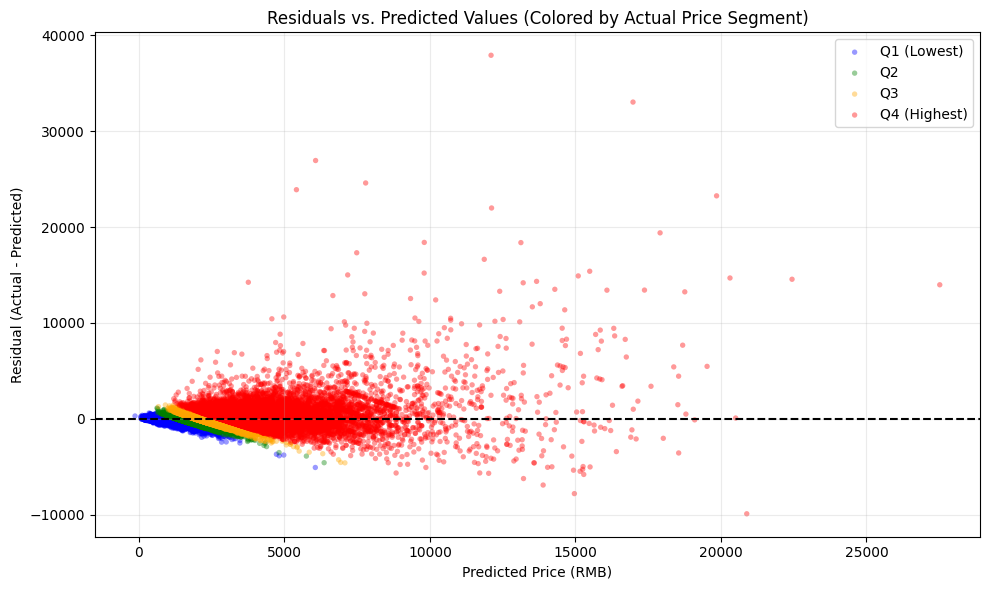

Enhanced residual plot saved to: d:\MACHINE LEARNING\knn_catboost_linear\catboost\outputs\residual_by_price_segment.png


In [ ]:
# Enhanced Residual Plot: Color by Price Segment
plt.figure(figsize=(10, 6))

# Scatter with colors by price segment
colors = {'Q1 (Lowest)': 'blue', 'Q2': 'green', 'Q3': 'orange', 'Q4 (Highest)': 'red'}
for segment, color in colors.items():
    subset = test_results[test_results['price_segment'] == segment]
    plt.scatter(subset['predicted'], subset['residual'], 
                alpha=0.4, s=15, c=color, label=segment, edgecolors='none')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Price (RMB)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values (Colored by Actual Price Segment)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_by_price_segment.png', dpi=220)
plt.show()
print(f"Enhanced residual plot saved to: {OUTPUT_DIR / 'residual_by_price_segment.png'}")